In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

#Additional libraries added for project:
import matplotlib.pyplot as plt
import seaborn as sns

#Data processing
from sklearn.impute import KNNImputer

#Model selection
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel

#ML
from xgboost import XGBRegressor

#DL
#import tensorflow as tf

#other
from IPython.display import Image, display
import warnings
warnings.filterwarnings('ignore');

# **Generation data**

In [ ]:
df_plt1_gen = pd.read_csv('Solar_Power_Plant_1_Generation_Data_Andra.csv')

df_plt1_gen.sample(10, random_state=1)

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
46554,07-06-2020 10:45,4135001,wCURE6d3bPkepu2,13377.571430,1304.642857,2164.714286,6955258.714
3080,16-05-2020 14:45,4135001,WRmjgnKYAwPKWDb,7123.428571,697.542857,5576.000000,7040391.000
43421,05-06-2020 22:30,4135001,rGa61gmuvPhdLxV,0.000000,0.000000,7741.000000,7273090.000
32552,31-05-2020 17:30,4135001,WRmjgnKYAwPKWDb,1402.428571,136.914286,5772.285714,7153801.286
57475,12-06-2020 15:00,4135001,VHMLBKoKgIrUVDU,5737.714286,562.285714,4963.714286,7419974.714
40726,04-06-2020 15:00,4135001,1BY6WEcLGh8j5v7,10714.250000,1047.225000,6008.500000,6403817.500
23568,27-05-2020 02:00,4135001,zBIq5rxdHJRwDNY,0.000000,0.000000,0.000000,6427702.000
36683,02-06-2020 16:30,4135001,YxYtjZvoooNbGkE,4555.857143,447.114286,7113.857143,7318629.857
31880,31-05-2020 09:45,4135001,sjndEbLyjtCKgGv,6312.875000,618.412500,1290.500000,7137545.500
29450,30-05-2020 06:15,4135001,WRmjgnKYAwPKWDb,318.375000,30.762500,4.625000,7140903.625


PLANT_ID is the same throughout, so it can be safely removed. The generation is 0 for nighttime, which of course makes sense for solar power. Also, let's rename to inverters/inverter column to make them easier to track.

In [ ]:
#Since we're focusing on plant 1 for now we'll shorten the name
df_gen = df_plt1_gen.drop('PLANT_ID', axis=1)

df_gen['INVERTER'] = df_gen.SOURCE_KEY.map({df_gen.SOURCE_KEY.unique()[i-1]: \
                                            f'INVERTER_{i}' for i in range(1, \
                                            len(df_gen.SOURCE_KEY.unique()) +1)})
df_gen = df_gen.drop('SOURCE_KEY', axis=1)
inverters = df_gen.INVERTER.unique()
inverters

array(['INVERTER_1', 'INVERTER_2', 'INVERTER_3', 'INVERTER_4',
       'INVERTER_5', 'INVERTER_6', 'INVERTER_7', 'INVERTER_8',
       'INVERTER_9', 'INVERTER_10', 'INVERTER_11', 'INVERTER_12',
       'INVERTER_13', 'INVERTER_14', 'INVERTER_15', 'INVERTER_16',
       'INVERTER_17', 'INVERTER_18', 'INVERTER_19', 'INVERTER_20',
       'INVERTER_21', 'INVERTER_22'], dtype=object)

In [ ]:
df_gen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59565 entries, 0 to 59564
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    59565 non-null  object 
 1   DC_POWER     59565 non-null  float64
 2   AC_POWER     59565 non-null  float64
 3   DAILY_YIELD  59565 non-null  float64
 4   TOTAL_YIELD  59564 non-null  float64
 5   INVERTER     59565 non-null  object 
dtypes: float64(4), object(2)
memory usage: 2.7+ MB


In [ ]:
df_gen.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
DATE_TIME,59565,2740,30-05-2020 08:30,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DC_POWER,59565.0,NaN,NaN,NaN,3219.483542,4095.355547,0.0,0.0,464.142857,6513.142857,14413.42857
AC_POWER,59565.0,NaN,NaN,NaN,314.821574,400.114601,0.0,0.0,44.9,637.7375,1405.3
DAILY_YIELD,59565.0,NaN,NaN,NaN,3240.212571,3155.066638,0.0,0.0,2425.285714,6265.428571,9163.0
TOTAL_YIELD,59564.0,NaN,NaN,NaN,6962462.355877,414710.050459,6183645.0,6486005.991,7133897.0,7250523.3925,7819361.429
INVERTER,59565,22,INVERTER_1,2736,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_gen.groupby('INVERTER').count().DATE_TIME.sort_values()

INVERTER
INVERTER_22    2685
INVERTER_7     2699
INVERTER_10    2700
INVERTER_3     2700
INVERTER_20    2700
INVERTER_2     2701
INVERTER_9     2704
INVERTER_15    2705
INVERTER_16    2705
INVERTER_21    2705
INVERTER_12    2706
INVERTER_5     2706
INVERTER_14    2706
INVERTER_17    2706
INVERTER_19    2707
INVERTER_18    2707
INVERTER_13    2711
INVERTER_8     2711
INVERTER_6     2714
INVERTER_4     2715
INVERTER_11    2736
INVERTER_1     2736
Name: DATE_TIME, dtype: int64

The dtypes make sense, but we'll need to make the DATE_TIME a datetime object for easier analysis. No nulls detected, but it looks like some data is missing. At the plant level we would expect 3264 unique timestamps (34 days 24 hours 4 (15 minute intervals in hour)), but there are only 3158. Across all inverters there would be 71808 rows (3264 * 22 (inverters)), but we only have 68778. So overall, around 3000 or ~4% of the total expected timestamps are missing. There is also some variance per inverter for what timestamps are missing as the above inverter row count shows.

In [ ]:
df_gen['DATE_TIME'] = pd.to_datetime(df_gen.DATE_TIME, format='%d-%m-%Y %H:%M')
df_gen.dtypes

DATE_TIME      datetime64[ns]
DC_POWER              float64
AC_POWER              float64
DAILY_YIELD           float64
TOTAL_YIELD           float64
INVERTER               object
dtype: object

# **Weather sensor data**

In [ ]:
df_plt1_weather = pd.read_csv('Solar_Power_Plant_1_Weather_Sensor_Data_Andra.csv')

df_plt1_weather.sample(10, random_state=1)

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
1194,2020-05-28 02:30:00,4135001,HmiyD2TTLFNqkNe,22.398088,20.536780,0.000000
2385,2020-06-09 16:45:00,4135001,HmiyD2TTLFNqkNe,29.618705,37.964126,0.302090
99,2020-05-16 03:30:00,4135001,HmiyD2TTLFNqkNe,21.731421,20.351884,0.000000
2779,2020-06-13 19:15:00,4135001,HmiyD2TTLFNqkNe,24.000767,21.948254,0.000000
13,2020-05-15 03:15:00,4135001,HmiyD2TTLFNqkNe,24.985215,24.351508,0.000000
2304,2020-06-08 20:30:00,4135001,HmiyD2TTLFNqkNe,24.091545,20.824284,0.000000
442,2020-05-19 18:00:00,4135001,HmiyD2TTLFNqkNe,25.046377,25.426198,0.001575
2847,2020-06-14 12:15:00,4135001,HmiyD2TTLFNqkNe,24.932560,36.606858,0.472765
45,2020-05-15 11:15:00,4135001,HmiyD2TTLFNqkNe,30.216062,50.006989,0.585787
705,2020-05-22 22:45:00,4135001,HmiyD2TTLFNqkNe,23.214526,21.719092,0.000000


In [ ]:
df_plt1_weather.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
DATE_TIME,3182,3182,2020-05-15 00:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PLANT_ID,3182.0,NaN,NaN,NaN,4135001.0,0.0,4135001.0,4135001.0,4135001.0,4135001.0,4135001.0
SOURCE_KEY,3182,1,HmiyD2TTLFNqkNe,3182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AMBIENT_TEMPERATURE,3182.0,NaN,NaN,NaN,25.531606,3.354856,20.398505,22.705182,24.613814,27.920532,35.252486
MODULE_TEMPERATURE,3182.0,NaN,NaN,NaN,31.091015,12.261222,18.140415,21.090553,24.61806,41.30784,65.545714
IRRADIATION,3182.0,NaN,NaN,NaN,0.228313,0.300836,0.0,0.0,0.024653,0.449588,1.221652


We can remove the PLANT_ID and SOURCE_KEY since they are the same throughout. Let's again make DATE_TIME a datetime object. Based on the DATE_TIME count we also have some missing weather data.

In [ ]:
df_weather = df_plt1_weather.drop(['PLANT_ID', 'SOURCE_KEY'], axis=1)
df_weather['DATE_TIME'] = pd.to_datetime(df_weather.DATE_TIME, format='%Y-%m-%d %H:%M:%S')

Filling out missing datetimes
In order to fill in the missing datetimes for our generation and weather sensor data set let's make a datetime object with the full range of expected datetimes.

In [ ]:
datetimes_full = pd.Series(pd.date_range(df_gen.DATE_TIME.min(),
                                         df_gen.DATE_TIME.max(),
                                         freq='15min'),
                           name='DATE_TIME')
datetimes_full

0      2020-05-15 00:00:00
1      2020-05-15 00:15:00
2      2020-05-15 00:30:00
3      2020-05-15 00:45:00
4      2020-05-15 01:00:00
               ...        
2839   2020-06-13 13:45:00
2840   2020-06-13 14:00:00
2841   2020-06-13 14:15:00
2842   2020-06-13 14:30:00
2843   2020-06-13 14:45:00
Name: DATE_TIME, Length: 2844, dtype: datetime64[ns]

Now we are ready to merge this will our data sets. Starting with the generation data set: since different inverters have some different datetimes missing we will need to do this one inverter at a time and then concatenate them back together.

In [ ]:
dfs_gen = []
for i in inverters:
    df_inverter = df_gen[df_gen.INVERTER == i]
    df_inverter = df_inverter.merge(datetimes_full, on='DATE_TIME', how='right')
    df_inverter['INVERTER'] = i
    dfs_gen.append(df_inverter)
df_gen = pd.concat(dfs_gen)
df_gen.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 62568 entries, 0 to 2843
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE_TIME    62568 non-null  datetime64[ns]
 1   DC_POWER     59565 non-null  float64       
 2   AC_POWER     59565 non-null  float64       
 3   DAILY_YIELD  59565 non-null  float64       
 4   TOTAL_YIELD  59564 non-null  float64       
 5   INVERTER     62568 non-null  object        
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 3.3+ MB


Now we can add the weather data to this as well to make our full dataframe.



In [ ]:
df = df_gen.merge(df_weather, on='DATE_TIME', how='left')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 62568 entries, 0 to 62567
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            62568 non-null  datetime64[ns]
 1   DC_POWER             59565 non-null  float64       
 2   AC_POWER             59565 non-null  float64       
 3   DAILY_YIELD          59565 non-null  float64       
 4   TOTAL_YIELD          59564 non-null  float64       
 5   INVERTER             62568 non-null  object        
 6   AMBIENT_TEMPERATURE  60764 non-null  float64       
 7   MODULE_TEMPERATURE   60764 non-null  float64       
 8   IRRADIATION          60764 non-null  float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 4.8+ MB


# **Standard**

Photovoltaic System Standards
Breadcrumb

Many organizations have established standards that address photovoltaic (PV) system component safety, design, installation, and monitoring.

Standards are norms or requirements that establish a basis for the common understanding and judgment of materials, products, and processes. Standards are an invaluable tool in industry and business, because they streamline business practices and provide a level playing field for businesses to develop products and services. They are also critical to ensuring that products and services are safe for consumers and the environment.

There are numerous national and international bodies that set standards for photovoltaics. There are standards for nearly every stage of the PV life cycle, including materials and processes used in the production of PV panels, testing methodologies, performance standards, and design and installation guidelines. The standards shown below are not a complete list but are those most relevant to the procurement and installation of solar PV systems. Each standard has been loosely categorized based on its subject matter.

International Electrotechnical Commission (IEC)
Balance of System
IEC 62093:2005: Balance-of-System Components for Photovoltaic Systems - Design Qualification Natural Environments
IEC 62109-1:2010: Safety of Power Converters for Use in Photovoltaic Power Systems - Part 1: General requirements
IEC 62109-2:2011: Safety of Power Converters for Use in Photovoltaic Power Systems - Part 2: Particular requirements for inverters
IEC 60269-6 ed1.0: Low-Voltage Fuses - Part 6: Supplementary requirements for fuse-links for the protection of solar photovoltaic energy systems
Characteristics
IEC 61727 ed2.0: Photovoltaic (PV) systems - Characteristics of the Utility Interface
Commissioning
IEC 62446-1:2016: Photovoltaic (PV) Systems - Requirements for Testing, Documentation, and Maintenance - Part 1: Grid connected systems - Documentation, commissioning tests and inspection.
Design
IEC 62124 ed1.0: Photovoltaic (PV) Stand-Alone Systems - Design Verification
IEC 62253 ed1.0: Photovoltaic Pumping Systems - Design Qualification and Performance Measurements
Installation
IEC 60364-1 ed5.0: Low-Voltage Electrical Installations - Part 1: Fundamental principles, assessment of general characteristics, definitions
IEC 60364-7-712:2017: Low-Voltage Electrical Installations - Part 7-712: Requirements for special installations or locations - Solar photovoltaic (PV) power supply systems
Monitoring
IEC 61724-1:2017: Photovoltaic System Performance - Part 1: Monitoring
IEC TS 61724-2:2016: Photovoltaic System Performance - Part 2: Capacity evaluation method
IEC TS 61724-3:2016: Photovoltaic System Performance - Part 3: Energy evaluation method
Performance
IEC 62509 ed1.0: Battery Charge Controllers for Photovoltaic Systems - Performance and Functioning
Rural Electrification
IEC TS 62257-1:2015: Recommendations for Renewable Energy and Hybrid Systems for Rural Electrification - Part 1: General introduction to IEC 62257 series and rural electrification
Safety
IEC 61730-1:2016: Photovoltaic (PV) Module Safety Qualification - Part 1: Requirements for construction
IEC 61730-2:2016: Photovoltaic (PV) Module Safety Qualification - Part 2: Requirements for testing
Terms
IEC TS 61836:2016: Solar Photovoltaic Energy Systems - Terms, Definitions and Symbols
Testing
IEC 61215-1:2016: Design Qualifications & Type Approval Part 1: Testing requirements (All chemistries)
IEC 61215-2:2016: Design Qualifications & Type Approval Part 2: Testing procedures (All chemistries)
IEC 62116:2014: Utility-Interconnected Photovoltaic Inverters - Test Procedure of Islanding Prevention Measures
Institute of Electrical and Electronics Engineers (IEEE)
Interconnection
IEEE 1547.2-2008: IEEE Application Guide for IEEE Std 1547(TM), IEEE Standard for Interconnecting Distributed Resources with Electric Power Systems
IEEE 1547.3-2007: IEEE Guide for Monitoring, Information Exchange, and Control of Distributed Resources Interconnected with Electric Power Systems
IEEE 1547-2018: IEEE Standard for Interconnection and Interoperability of Distributed Energy Resources with Associated Electric Power Systems Interfaces
Performance
IEEE 1526-2003: IEEE Recommended Practice for Testing the Performance of Stand-Alone Photovoltaic Systems
Sizing
IEEE 1562-2007: IEEE Guide for Array and Battery Sizing in Stand-Alone Photovoltaic (PV) Systems
Underwriters Laboratories (UL)
Balance of System
UL-2703, 1st Edition: Standard for Mounting Systems, Mounting Devices, Clamping/Retention Devices, and Ground Lugs for Use with Flat-Plate Photovoltaic Modules and Panels
UL 1741: Standard for Inverters, Converters, Controllers and Interconnection System Equipment for Use With Distributed Energy Resources
UL-1699B: Standard for Photovoltaic (PV) DC Arc-Fault Circuit Protection
UL-4703: Standard for Photovoltaic Wire
UL-854: Standard for Service - Entrance Cables
UL-4248-19: Fuseholders - Part 19: Photovoltaic
UL-6703: Standards for Connectors for Use in Photovoltaic Systems
UL-3730: Standard for Photovoltaic Junction Boxes
UL-489B, 1st Edition: Molded-Case Circuit Breakers, Molded-Case Switches, and Circuit-Breaker Enclosures for Use with Photovoltaic (PV) Systems
Concentrated
UL 8703, 3rd Edition: Concentrator Photovoltaic Modules and Assemblies
Flat-Plate PV
UL 1703, 3rd Edition: Standard for Flat-Plate Photovoltaic Modules and Panels
Mounting
UL 790, 8th Edition: Standard for Standard Test Methods for Fire Tests of Roof Coverings
UL 1897, 7th Edition: Standard for Uplift Tests for Roof Covering Systems
Testing
UL-SU 5703: Determination of the Maximum Operating Temperature Rating of Photovoltaic (PV) Backsheet Materials
American Society for Testing and Materials (ASTM)
Terms
ASTM E772 - 15: Standard Terminology of Solar Energy Conversion
Testing
# ASTM E2848 - 13(2018) : Standard Test Method for Reporting Photovoltaic Non-Concentrator System Performance

	Technology	Bifacial	STC	PTC	A_c	Length	Width	N_s	I_sc_ref	V_oc_ref	...	a_ref	I_L_ref	I_o_ref	R_s	R_sh_ref	Adjust	gamma_r	BIPV	Version	Date
A10Green_Technology_A10J_S72_175	Mono-c-Si	0	175.0914	151.2	1.3	1.576	0.825	72	5.17	43.99	...	1.981696	5.175703	0.0	0.316688	287.102203	16.057121	-0.5072	N	SAM 2018.11.11 r2	1/3/2019
A10Green_Technology_A10J_S72_180	Mono-c-Si	0	179.928	155.7	1.3	1.576	0.825	72	5.31	44.06	...	1.988414	5.316148	0.0	0.299919	259.047943	16.418983	-0.5072	N	SAM 2018.11.11 r2	1/3/2019
A10Green_Technology_A10J_S72_185	Mono-c-Si	0	184.7016	160.2	1.3	1.576	0.825	72	5.43	44.14	...	1.984817	5.435676	0.0	0.311962	298.424438	15.688233	-0.5072	N	SAM 2018.11.11 r2	1/3/2019
A10Green_Technology_A10J_M60_220	Multi-c-Si	0	219.876	189.1	1.624	1.632	0.995	60	7.95	36.06	...	1.673094	7.959062	0.0	0.140393	123.168404	21.875164	-0.5196	N	SAM 2018.11.11 r2	1/3/2019
A10Green_Technology_A10J_M60_225	Multi-c-Si	0	224.9856	193.5	1.624	1.632	0.995	60	8.04	36.24	...	1.671782	8.047206	0.0	0.14737	164.419479	20.698376	-0.5196	N	SAM 2018.11.11 r2	1/3/2019

# **Exploratory Data Analysis**
To start our more in-depth analysis, we'll make some basic datetime features. If we were modeling throughout the year(s), month and year could be interesting to account for seasonal variation and long-term trends, but since our data only covers 34 days, we will omit them. We can use dayofyear to capture any longer trends that might be present.

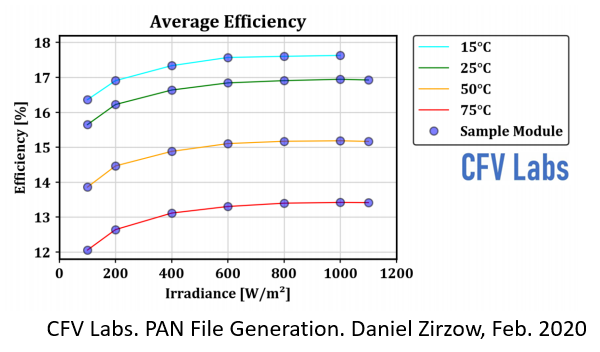

In [ ]:
df['HOUR'] = df.DATE_TIME.dt.hour
df['DAY'] = df.DATE_TIME.dt.dayofyear
df['DAY_WEEK'] = df.DATE_TIME.dt.dayofweek
df['MINUTES_15'] = df.DATE_TIME.dt.time

#This maps the 15 minute intervals over the course of the day to ints 1-96.
df['MINUTES_15'] = df.MINUTES_15.map({df.MINUTES_15.unique()[i-1]:i for i in range(1, 97)})
#Change day of year to day of data
df['DAY'] = df.DAY.map({df.DAY.unique()[i-1]:i for i in range(1, 30)})

In [ ]:
corr = df.corr(numeric_only=True)
corr

,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,DAY,DAY_WEEK,MINUTES_15
DC_POWER,1.000000,0.999996,0.100377,0.007091,0.722552,0.955863,0.989998,3.451033e-02,-2.069773e-02,0.016036,3.455911e-02
AC_POWER,0.999996,1.000000,0.100353,0.007067,0.722818,0.955993,0.989954,3.452630e-02,-2.068471e-02,0.016041,3.457395e-02
DAILY_YIELD,0.100377,0.100353,1.000000,0.002721,0.506532,0.219854,0.096320,8.220854e-01,-1.214301e-02,0.006522,8.221552e-01
TOTAL_YIELD,0.007091,0.007067,0.002721,1.000000,-0.028377,-0.010240,-0.000324,1.270815e-03,1.497317e-01,-0.008268,1.269618e-03
AMBIENT_TEMPERATURE,0.722552,0.722818,0.506532,-0.028377,1.000000,0.851544,0.719893,3.397534e-01,-1.965942e-01,0.060596,3.394158e-01
MODULE_TEMPERATURE,0.955863,0.955993,0.219854,-0.010240,0.851544,1.000000,0.961914,1.148077e-01,-7.951587e-02,0.038232,1.146418e-01
IRRADIATION,0.989998,0.989954,0.096320,-0.000324,0.719893,0.961914,1.000000,2.433877e-02,-1.816297e-02,0.019039,2.437588e-02
HOUR,0.034510,0.034526,0.822085,0.001271,0.339753,0.114808,0.024339,1.000000e+00,2.137404e-16,-0.013402,9.991824e-01
DAY,-0.020698,-0.020685,-0.012143,0.149732,-0.196594,-0.079516,-0.018163,2.137404e-16,1.000000e+00,-0.087706,-1.178474e-17
DAY_WEEK,0.016036,0.016041,0.006522,-0.008268,0.060596,0.038232,0.019039,-1.340202e-02,-8.770580e-02,1.000000,-1.339106e-02


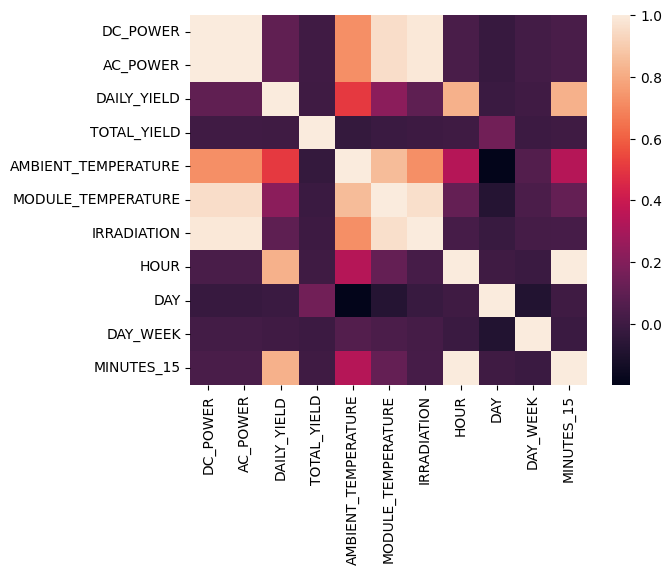

In [ ]:
sns.heatmap(corr);

Not surprisingly DC and AC power are highly correlated. This is good! It probably means the inverters in the plant are working correctly to convert the DC to AC. We will ultimately make AC_POWER our target. There is a strong correlation between HOUR and DAILY_YIELD, which makes sense as the daily yield increases throughout the day. For the weather sensor data there is a strong correlation between IRRADIATION and AC_POWER. Also, between MODULE_TEMPERATURE and AC_POWER. Now we will look at a pairplot to see another representation of these relationships and look for any non-linear correlations.

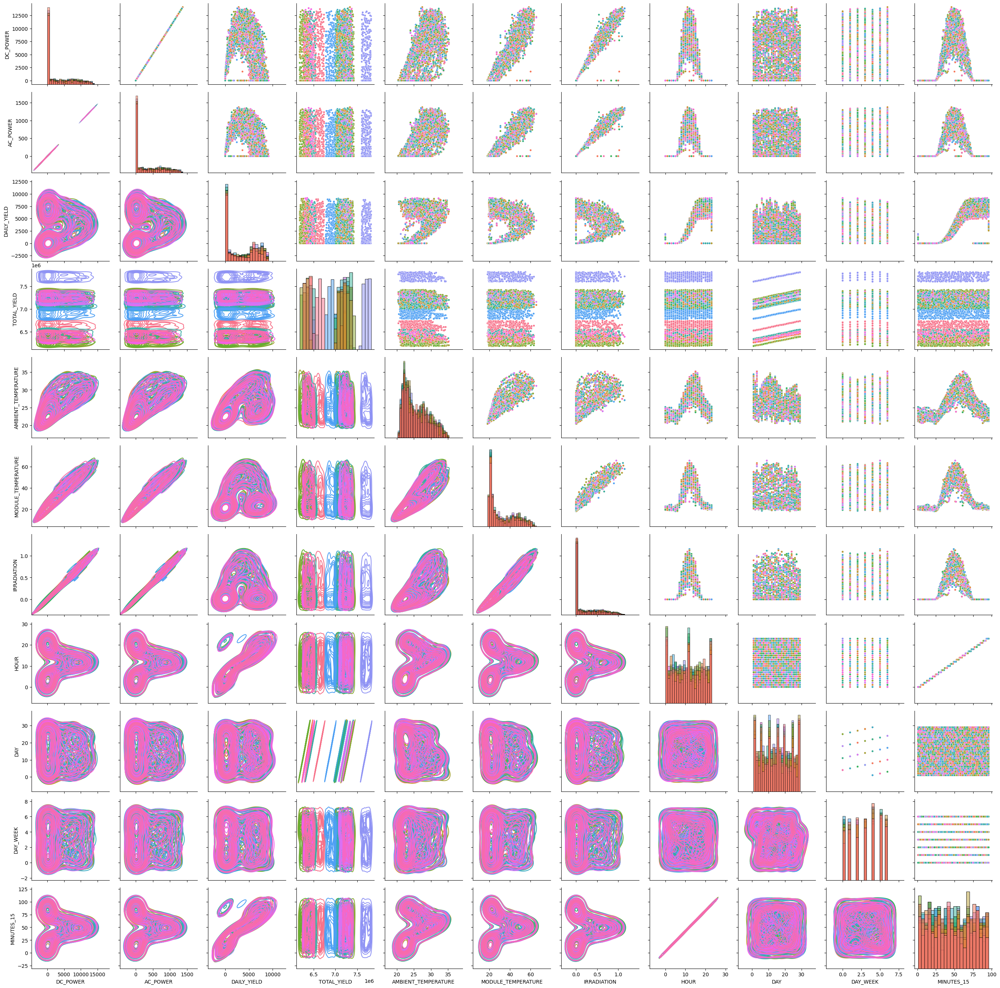

In [ ]:
g = sns.PairGrid(df.sample(10000, random_state=1), diag_sharey=False, hue='INVERTER')
g.map_upper(sns.scatterplot, s=15)
g.map_lower(sns.kdeplot)
g.map_diag(sns.histplot);
#This takes quite a while to run, so saving this figure for future use.
# plt.savefig("gen_pairgrid.png", dpi=400)
# display(Image(filename='gen_pairgrid.png'))

Outliers
First a quick check for any negative power numbers.

In [ ]:
df[['AC_POWER', 'DC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']].any() < 0

AC_POWER       False
DC_POWER       False
DAILY_YIELD    False
TOTAL_YIELD    False
dtype: bool

They should only be positive and luckily that appears to be the case.


Target outliers
Let's now explore our target, AC_POWER. We can define an outlier as \< 1st percentile or > 99th percentile. To do this I will make four quantile features below: 2 of them in the outlier range and 2 to establish 1 standard deviation from the mean. Then we can plot the results.

In [ ]:
#Making a new dataframe for EDA since we won't necessarily want these features for our model.
df_eda = df.copy()
df_eda = df_eda.merge(df_eda.groupby('MINUTES_15')\
                      .quantile(0.01, numeric_only=True)\
                      .AC_POWER.rename('OUTLIERS_LOW_AC_POWER'),
                      on='MINUTES_15',
                      how='left')
df_eda = df_eda.merge(df_eda.groupby('MINUTES_15')\
                      .quantile(0.99, numeric_only=True)\
                      .AC_POWER.rename('OUTLIERS_HIGH_AC_POWER'),
                      on='MINUTES_15',
                      how='left')
df_eda = df_eda.merge(df_eda.groupby('MINUTES_15')\
                      .mean(numeric_only=True)\
                      .AC_POWER.rename('MEAN'),
                       on='MINUTES_15',
                       how='left')
df_eda = df_eda.merge(df_eda.groupby('MINUTES_15')\
                      .std(numeric_only=True)\
                      .AC_POWER\
                      .rename('STD'),
                      on='MINUTES_15',
                      how='left')
df_eda['STD_1'] = df_eda.query('AC_POWER < (MEAN + STD) and AC_POWER > (MEAN - STD)').AC_POWER

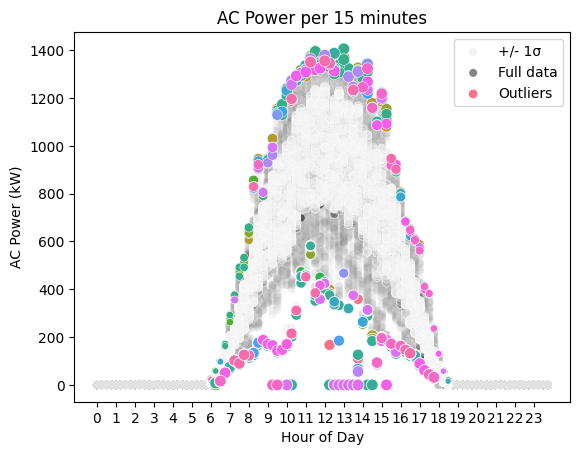

In [ ]:
#Since we have nulls in our data now we will exclude those with df[~df.isna()]
fig, ax = plt.subplots()
sns.color_palette("Paired")
sns.scatterplot(data=df_eda[~df_eda.isna()],
                y='AC_POWER', x='MINUTES_15',
                hue='INVERTER', palette='gray', alpha=0.05, legend=False)
sns.scatterplot(data=df_eda[~df_eda.isna()],
                y='STD_1', x='MINUTES_15',
                hue='INVERTER', palette='gray', alpha =0.5, legend=False)
sns.scatterplot(data=df_eda[~df_eda.isna()].query('AC_POWER > OUTLIERS_HIGH_AC_POWER'),
                y='AC_POWER', x='MINUTES_15',
                hue='INVERTER', size='AC_POWER')
sns.scatterplot(data=df_eda[~df_eda.isna()].query('AC_POWER < OUTLIERS_LOW_AC_POWER'),
                y='AC_POWER', x='MINUTES_15',
                hue='INVERTER', size= -df_eda[~df_eda.isna()].AC_POWER)

plt.title('AC Power per 15 minutes')
plt.ylabel('AC Power (kW)')
plt.xlabel('Hour of Day')
ax.set_xticks([i for i in range(1, 97, 4)])
ax.set_xticklabels([i for i in range(24)])
ax.legend(['+/- 1\u03C3','Full data', 'Outliers']);

Interestingly, it looks like there are several instances where the power generated during the middle of the day was 0. This could either indicate bad data, malfunctioning inverters, some kind of planned maintenance, cloudy days, sunny days where the plant is overheating/at capacity or any number of other things. Without having a deeper domain knowledge, it is hard to know for sure, but let's see if we can find any pattern to these mid-day outliers.

First, we'll check to see if any inverters in particular are responsible.

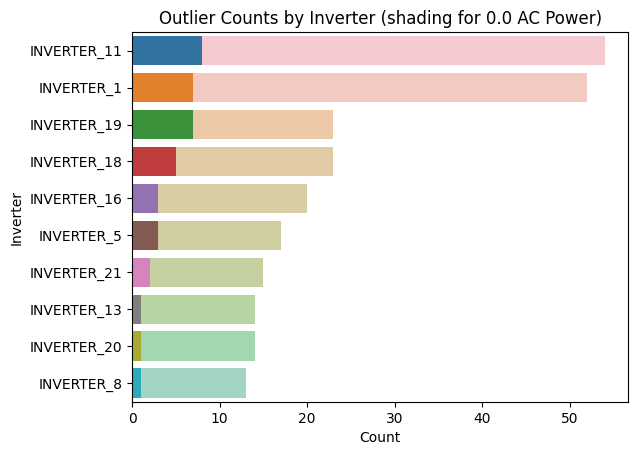

In [ ]:
outliers_low = df_eda[~df_eda.isna()].query('AC_POWER < OUTLIERS_LOW_AC_POWER')
outliers_high = df_eda[~df_eda.isna()].query('AC_POWER > OUTLIERS_HIGH_AC_POWER')

outliers_source_low = outliers_low.groupby('INVERTER')\
                                  .count()\
                                  .DATE_TIME\
                                  .reset_index()\
                                  .sort_values('DATE_TIME', ascending=False)
outliers_source_low_zero = outliers_low[outliers_low.AC_POWER == 0].groupby('INVERTER')\
                                                    .count()\
                                                    .DATE_TIME\
                                                    .reset_index()\
                                                    .sort_values('DATE_TIME', ascending=False)
fig, ax = plt.subplots()
sns.barplot(data = outliers_source_low,
            y='INVERTER', x='DATE_TIME',
            alpha = 0.5, )
sns.barplot(data = outliers_source_low_zero,
            y='INVERTER', x='DATE_TIME')
plt.title('Outlier Counts by Inverter (shading for 0.0 AC Power)')
plt.ylabel('Inverter')
plt.xlabel('Count');

The spread of outlier counts, including the 0.0 AC_POWER measurements are concentrated in inverters 11 and 1. It could be that these were offline for an extended period due to maintenance or malfunction. Below we'll look at the spread of the outliers over the course of the full 34 days to see if there is any regularity.

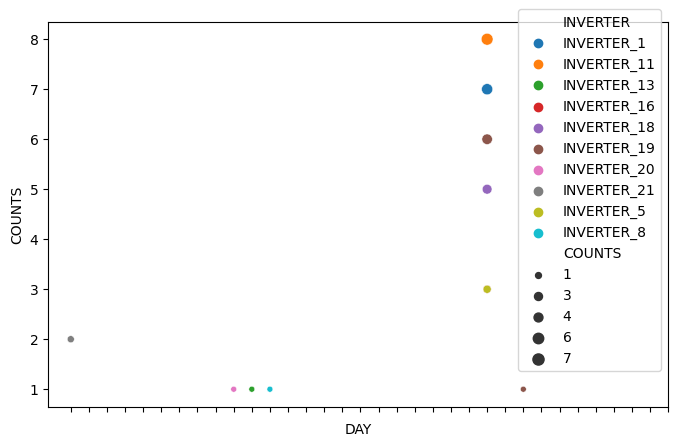

In [ ]:
outliers_zero_count = outliers_low[outliers_low.AC_POWER == 0].groupby(['INVERTER','DAY'])\
                                                              .count()\
                                                              .rename(columns={'AC_POWER':'COUNTS'})\
                                                              .COUNTS\
                                                              .reset_index()
outliers_zero_count
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=outliers_zero_count,
                x='DAY', y='COUNTS',
                hue='INVERTER', size='COUNTS', legend='brief')
ax.legend(bbox_to_anchor=(1, 1.05))
ax.set_xticks([i for i in range(1,35)]);
ax.set_xticklabels([]);

Several occur on the same day. There could have been maintenance that day or another issue. Now let's check for any weekly patterns.

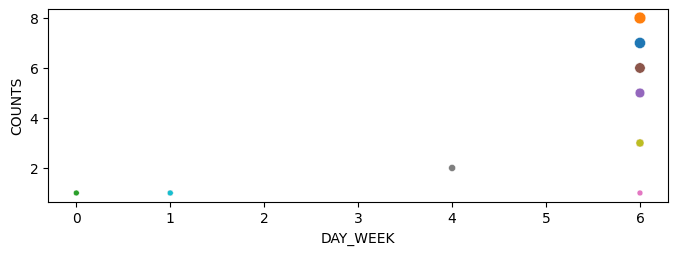

In [ ]:
outliers_zero_count = outliers_low[outliers_low.AC_POWER == 0].groupby(['INVERTER','DAY_WEEK'])\
                                                              .count()\
                                                              .rename(columns={'AC_POWER':'COUNTS'})\
                                                              .COUNTS\
                                                              .reset_index()
outliers_zero_count
fig, ax = plt.subplots(figsize=(8,2.5))
sns.scatterplot(data=outliers_zero_count,
                x='DAY_WEEK', y='COUNTS',
                hue='INVERTER', size='COUNTS', legend=False);

Several of the zeros occur on Sunday. This could still be coincidence, or it might suggest some scheduled maintenance. Since Sunday is likely a day with less demand on the grid, it would make sense to choose that as a day for maintenance or some planned outage. Let's circle back and check on the non-zero outliers as well.

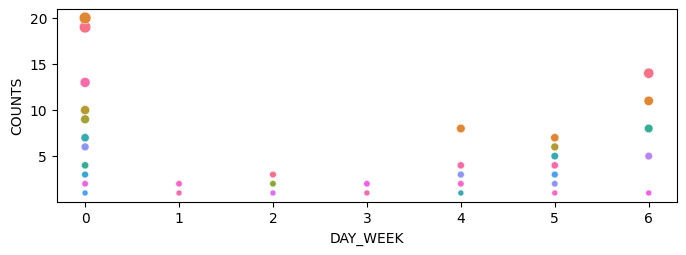

In [ ]:
outliers_low_count = outliers_low.groupby(['INVERTER','DAY_WEEK'])\
                                 .count()\
                                 .rename(columns={'AC_POWER':'COUNTS'})\
                                 .COUNTS\
                                 .reset_index()
fig, ax = plt.subplots(figsize=(8,2.5))
sns.scatterplot(data=outliers_low_count,
                x='DAY_WEEK', y='COUNTS',
                hue='INVERTER', size='COUNTS', legend=False);

There are a greater number of overall outliers on Monday. We might guess that after Sunday maintenance there is a delay getting everything back online that goes into Monday. I think there is enough evidence now to choose to keep these outliers in our data as it might help the model account for some of this. That being said the number is low enough that it likely won't have too much of an impact.

Other Outliers
Let's take a quick look at outliers in the other features, before moving to missing data. Since we'll be exploring several different features we can make a function to help streamline the process.

In [ ]:
def outliers(df, feature, high_per, low_per, source_key=True):
    df = df.copy()
    df = df.merge(df.groupby('MINUTES_15')\
                  .quantile(low_per, numeric_only=True)[feature]\
                  .rename(f'OUTLIERS_LOW_{feature}'),
                  on='MINUTES_15',
                  how='left')
    df = df.merge(df.groupby('MINUTES_15')\
                  .quantile(high_per, numeric_only=True)[feature]\
                  .rename(f'OUTLIERS_HIGH_{feature}'),
                  on='MINUTES_15',
                  how='left')
    df = df.merge(df.groupby('MINUTES_15')\
                  .mean(numeric_only=True)[feature]\
                  .rename(f'MEAN_{feature}'),
                  on='MINUTES_15',
                  how='left')
    df = df.merge(df.groupby('MINUTES_15')\
                  .std(numeric_only=True)[feature]\
                  .rename(f'STD_{feature}'),
                  on='MINUTES_15',
                  how='left')
    df[f'STD_1_{feature}'] = df.query(f'{feature} < (MEAN_{feature} + STD_{feature}) \
                                      and {feature} > (MEAN_{feature} - STD_{feature})')[feature]

    fig, ax = plt.subplots()
    sns.color_palette("Paired")
    if source_key == True:
        sns.scatterplot(data=df,
                        y=feature, x='MINUTES_15',
                        hue='INVERTER', palette='gray', alpha=0.05, legend=False)
        sns.scatterplot(data=df,
                        y=f'STD_1_{feature}', x='MINUTES_15',
                        hue='INVERTER', palette='gray', alpha =0.5, legend=False)
        sns.scatterplot(data=df.query(f'{feature} > OUTLIERS_HIGH_{feature}'),
                        y=feature, x='MINUTES_15',
                        hue='INVERTER', size=feature)
        sns.scatterplot(data=df.query(f'{feature} < OUTLIERS_LOW_{feature}'),
                        y=feature, x='MINUTES_15',
                        hue='INVERTER', size= -df[feature])
    else:
        sns.scatterplot(data=df,
                        y=feature, x='MINUTES_15',
                        color='gray', alpha=0.05, legend=False)
        sns.scatterplot(data=df,
                        y=f'STD_1_{feature}', x='MINUTES_15',
                        color='gray', alpha =0.5, legend=False)
        sns.scatterplot(data=df.query(f'{feature} > OUTLIERS_HIGH_{feature}'),
                        y=feature, x='MINUTES_15',
                        color='blue', size=feature)
        sns.scatterplot(data=df.query(f'{feature} < OUTLIERS_LOW_{feature}'),
                        y=feature, x='MINUTES_15',
                        color='red', size= -df[feature])

    plt.title(f'{feature} per 15 minutes')
    plt.ylabel(f'{feature}')
    plt.xlabel('Hour of Day')
    ax.set_xticks([i for i in range(1, 97, 4)])
    ax.set_xticklabels([i for i in range(24)])
    ax.legend(['Full data', '+/- 1\u03C3', 'Outliers']);
    return ax, df

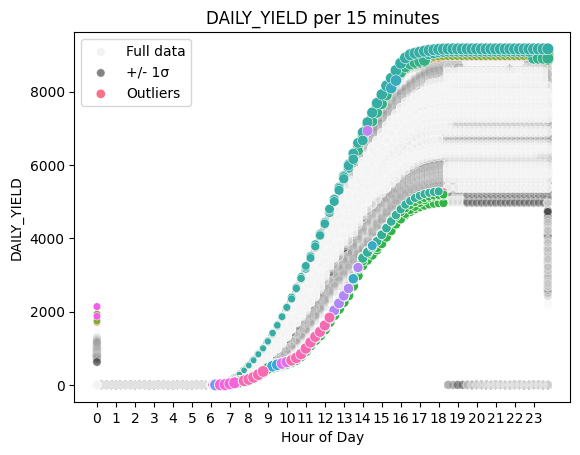

In [ ]:
ax_daily_yield, df_daily_yield = outliers(df_eda[~df_eda.isna()], 'DAILY_YIELD', 0.99, 0.01);

There are some unusual things happening here. Mainly the 0s after 6pm. The straight line down at the end of the day and the other line at the start. These seem like they could be incorrect data, or maybe some kind of correction of previous data. Whatever their exact cause, it is probably best to correct these to make the data less disconnected and ultimately help our model. To fix these we'll make every value during the night equal to the maximum daily yield and set all the daily yields at the beginning of the day to 0.

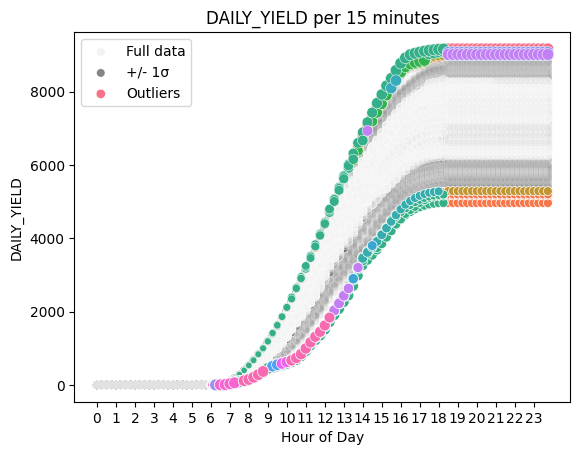

In [ ]:
#Had a go through a few trys to settle on MINUTES_15 = 75 as a good starting point for night.
nighttime = [i for i in range(75,97)]
#Making these changes to the original df
df['DAILY_YIELD'] = df['DAILY_YIELD'].mask(df.HOUR.isin([0]), 0)
#We need a maximun daily yield for each inverter seperately
daily_yield = df.copy()
daily_yield = df.merge(pd.DataFrame({'DAILY_YIELD_DAY_MAX' : df.groupby([ 'INVERTER', 'DAY']).max()['DAILY_YIELD']})\
                       .reset_index(),
                       on=['INVERTER', 'DAY'],
                       how='right')
df['DAILY_YIELD'] = df['DAILY_YIELD'].mask(df.MINUTES_15.isin(nighttime),
                                           daily_yield['DAILY_YIELD_DAY_MAX'])

ax_daily_yield, df_daily_yield = outliers(df[~df.isna()], 'DAILY_YIELD', 0.99, 0.01);

This is better now. It remains to be seen how much of an impact daily yield has on our model, but this should help at least a little.

# **Imputing missing values**
Now we are ready to impute the missing values as a final step before beginning our modeling. First, let's find a section of missing data to use as a test case for how effective our imputer is.

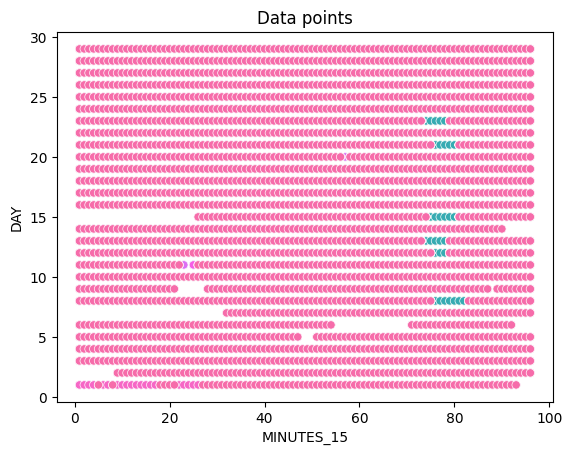

In [ ]:
sns.scatterplot(data=df[~df.AC_POWER.isna()],
                x='MINUTES_15', y='DAY',
                hue='INVERTER', legend=False)
plt.title('Data points');

There is a fair bit of missing data on day 6, so we can use this day to test our imputer with a before and after plot.

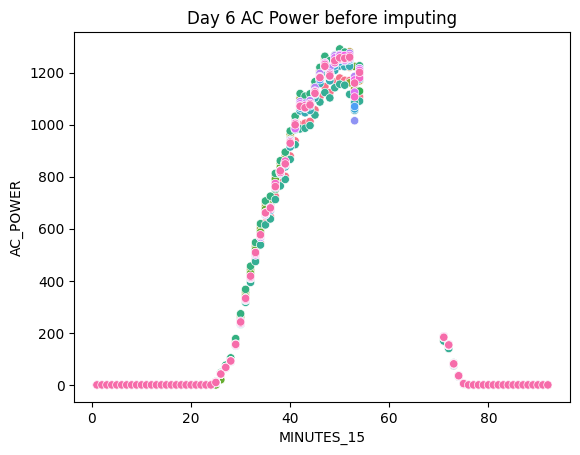

In [ ]:
sns.scatterplot(data=df[~df.isna()][df.DAY == 6],
                x='MINUTES_15', y='AC_POWER',
                hue='INVERTER', legend=False);
plt.title('Day 6 AC Power before imputing');

Now we can impute the other missing values. Let's try a couple of different methods and see what is more effective. We'll pick sklearn KNNImputer and also, based on this article, the built-in pandas method interpolate, with the time method specifically. For best results we will apply our imputer to each inverter individually and then concatenate them together.

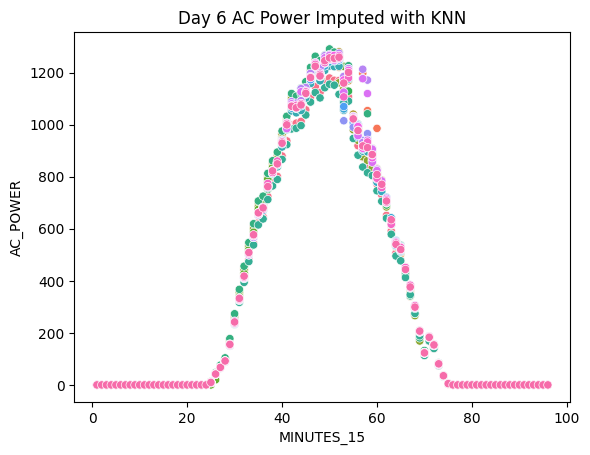

In [ ]:
imputer = KNNImputer(n_neighbors=10)
inverter_dfs = []
inverter_df = None
for i in inverters:
    inverter_df = df[df.INVERTER == i]
    inverter_df.pop('INVERTER')
    inverter_df.index = inverter_df['DATE_TIME']
    datetime = inverter_df.pop('DATE_TIME')
    inverter_df = pd.DataFrame(imputer.fit_transform(inverter_df),
                               columns=inverter_df.columns,
                               index=datetime)
    inverter_df['INVERTER'] = i
    inverter_df = inverter_df.reset_index()
    inverter_dfs.append(inverter_df)
df_knn = pd.concat(inverter_dfs)

sns.scatterplot(data=df_knn[df_knn.DAY == 6],
                x='MINUTES_15', y='AC_POWER',
                hue='INVERTER', legend=False);
plt.title('Day 6 AC Power Imputed with KNN');

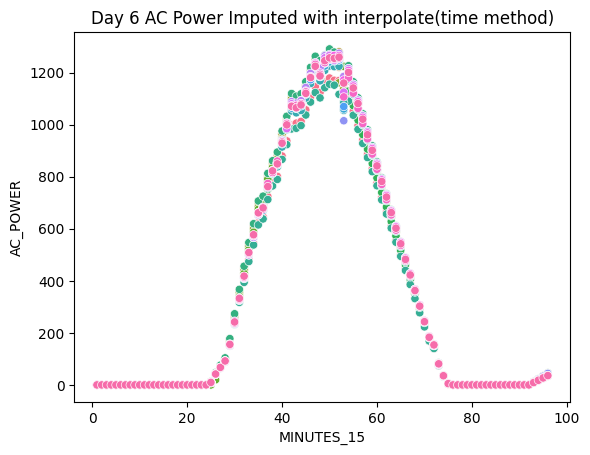

In [ ]:
inverter_dfs = []
inverter_df = None
for i in inverters:
    inverter_df = df[df.INVERTER == i]
    inverter_df.pop('INVERTER')
    inverter_df.index = inverter_df['DATE_TIME']
    datetime = inverter_df.pop('DATE_TIME')
    inverter_df = inverter_df.interpolate(method='time')
    inverter_df['INVERTER'] = i
    inverter_df = inverter_df.reset_index()
    inverter_dfs.append(inverter_df)
df_interpolate = pd.concat(inverter_dfs)
sns.scatterplot(data=df_interpolate[df_interpolate.DAY == 6],
                x='MINUTES_15', y='AC_POWER',
                hue='INVERTER', legend=False);

plt.title('Day 6 AC Power Imputed with interpolate(time method)');

Both imputation methods seem to work pretty well, however, the KNNImputer appears to capture a bit more of the nuance of the data, so we will choose that. Let's also make an imputer function.

In [ ]:
def imputer(df, imputer=KNNImputer(n_neighbors=10)):
    imputer = imputer
    inverter_dfs = []
    inverter_df = None
    for i in inverters:
        inverter_df = df[df.INVERTER == i]
        inverter_df.pop('INVERTER')
        inverter_df.index = inverter_df['DATE_TIME']
        datetime = inverter_df.pop('DATE_TIME')
        inverter_df = pd.DataFrame(imputer.fit_transform(inverter_df),
                                   columns=inverter_df.columns,
                                   index=datetime)
        inverter_df['INVERTER'] = i
        inverter_df = inverter_df.reset_index()
        inverter_dfs.append(inverter_df)
    df = pd.concat(inverter_dfs)
    return df

df = imputer(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 62568 entries, 0 to 2843
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            62568 non-null  datetime64[ns]
 1   DC_POWER             62568 non-null  float64       
 2   AC_POWER             62568 non-null  float64       
 3   DAILY_YIELD          62568 non-null  float64       
 4   TOTAL_YIELD          62568 non-null  float64       
 5   AMBIENT_TEMPERATURE  62568 non-null  float64       
 6   MODULE_TEMPERATURE   62568 non-null  float64       
 7   IRRADIATION          62568 non-null  float64       
 8   HOUR                 62568 non-null  float64       
 9   DAY                  62568 non-null  float64       
 10  DAY_WEEK             62568 non-null  float64       
 11  MINUTES_15           62568 non-null  float64       
 12  INVERTER             62568 non-null  object        
dtypes: datetime64[ns](1), float64(11

Target
Before establishing a baseline, we need to create our target. As mentioned previously, our target will be the sum of the AC power generation between all the inverters for a given 15 minute interval forecasted ahead to the next day. So, let's make the target and examine it a bit more closely before establishing a baseline.

In [ ]:
day = 96
#shifting to day ahead and dropping nulls cause by the shift
target = df.groupby('DATE_TIME').sum(numeric_only=True).AC_POWER.shift(-day)
target = target.dropna()

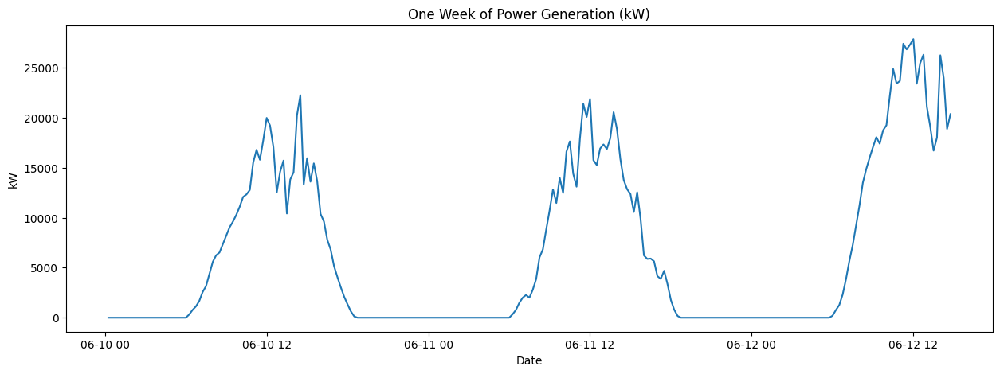

In [ ]:
fig, ax = plt.subplots(figsize=(15,5))
sns.lineplot(target[target.index > '2020-06-10'])
plt.title('One Week of Power Generation (kW)')
plt.xlabel('Date')
plt.ylabel('kW');

This is what we will be modeling. There are a lot valleys and sharp peaks. Modeling the inverters separately or including all the inverter generation data in the model could help address this.

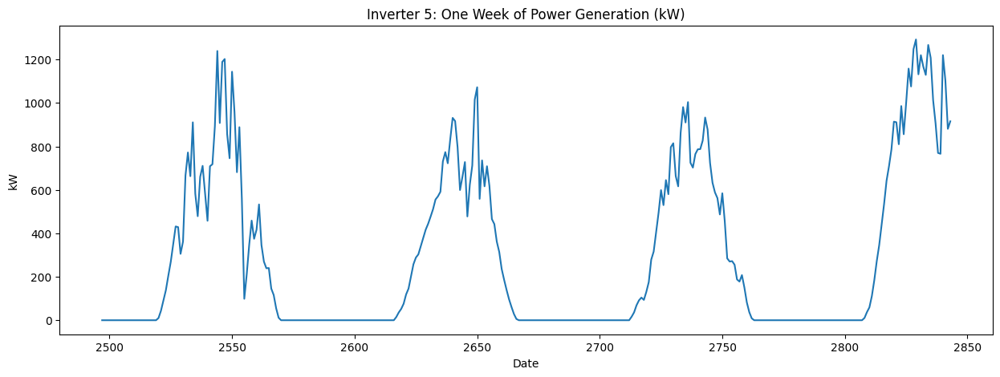

In [ ]:
fig, ax = plt.subplots(figsize=(15,5))
sns.lineplot(df[(df.INVERTER == inverters[5]) & (df.DATE_TIME > '2020-06-10')].AC_POWER)
plt.title('Inverter 5: One Week of Power Generation (kW)')
plt.xlabel('Date')
plt.ylabel('kW');

However, looking at just one inverter actually doesn't seem to smooth out the data any, so the difference between including the inverter data separately or just aggregating might be negligible. Either way, we'll explore both to compare the results. Let's look at the hourly results.

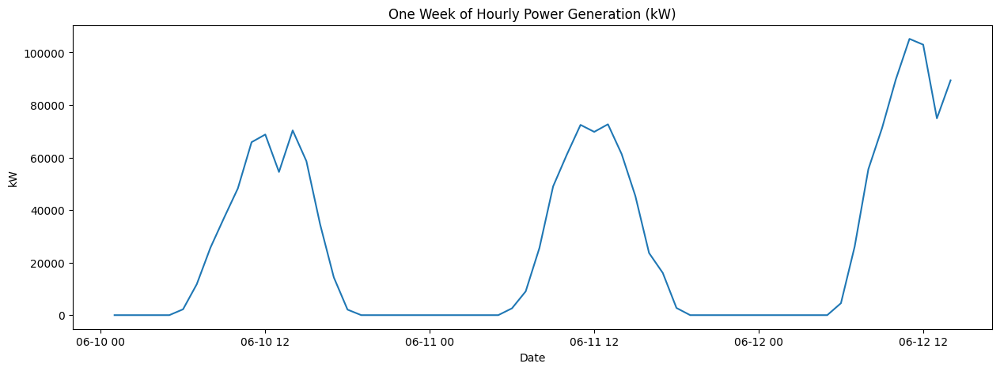

In [ ]:
target_hour = target.resample('H').sum()

fig, ax = plt.subplots(figsize=(15,5))
sns.lineplot(target_hour[target_hour.index > '2020-06-10'])
plt.title('One Week of Hourly Power Generation (kW)')
plt.xlabel('Date')
plt.ylabel('kW');

This is much smoother and might be easier for the model to handle. Some of the features we make later might be able to take advantage of this, but our ultimate goal is the 15 min AC power generation.

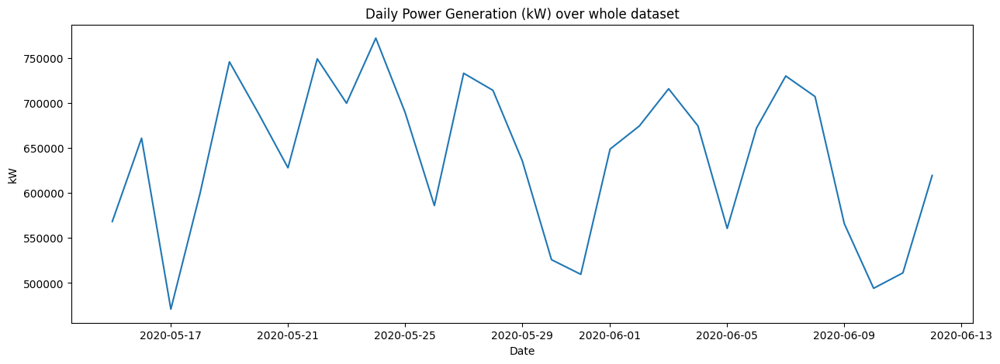

In [ ]:
target_day = target.resample('D').sum()
fig, ax = plt.subplots(figsize=(15,5))
sns.lineplot(target_day)
plt.title('Daily Power Generation (kW) over whole dataset')
plt.xlabel('Date')
plt.ylabel('kW');

It looks like there might be some longer trends present in the generation, possibly due to the weather patterns. We will try to include some features that could capture this in our model.

Time series decomposition

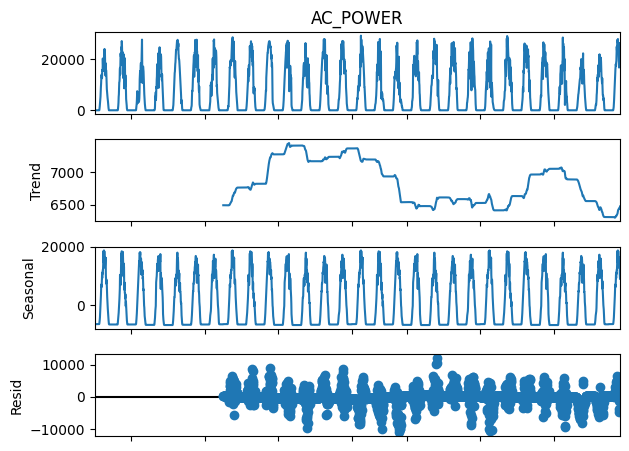

In [ ]:
result_decompose=seasonal_decompose(target,
                                    model='additive',
                                    period=96*7,
                                    two_sided=False);
fig = result_decompose.plot()
fig.axes[0].set_xticklabels("")
fig.axes[1].set_xticklabels("")
fig.axes[2].set_xticklabels("")
fig.axes[3].set_xticklabels("");

Decomposing our target captures some of the trends a bit better. Of course, the daily pattern is again clear. The residual plot does show quite a bit of noise, which will be challenging for our model to handle. Maybe some of the exogenous features can help with this.

Establishing Baseline
We are now ready to establish a baseline. Our baseline will be that the generation was the same as the day before at the same 15 minute interval. We will use root mean squared error (RMSE) scoring throughout and set aside the last 4 days of data to test between models. This will give us 3 days to work with since we are forecasting a day ahead. RMSE is used to give our model an extra penalty for large errors (since the errors are squared in the calculation). It also puts the score in the same units as our target (kW). The smaller the score the better.

In [ ]:
day = 96
#last 3 days for testing and the rest for training
target_test = target[-3*day:]
target_train = target[:-3*day]
#moving target back a day
baseline_preds = target.shift(day)[-3*day:]
baseline_score = np.round(mean_squared_error(target_test,
                                             baseline_preds,
                                             squared=False),
                          4)
print('baseline_score: ', baseline_score)

baseline_score:  3624.0212


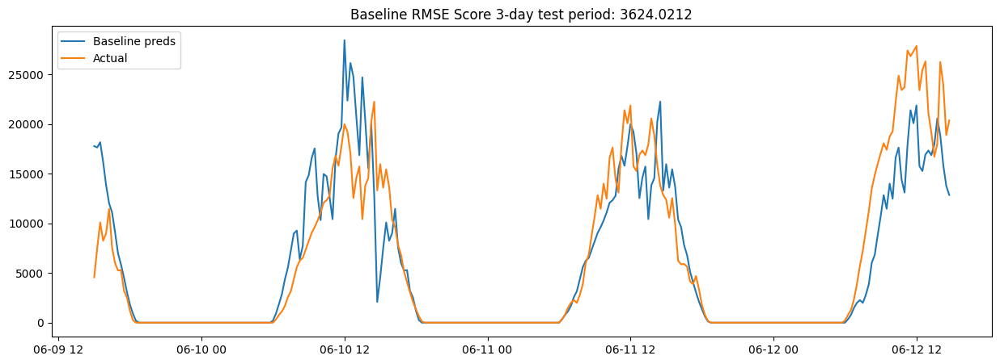

In [ ]:
fig, ax = plt.subplots(figsize=(15,5))
# plt.plot(X[X.index > '2020-06-10'].index, y_pred[X.index > '2020-06-10'], alpha=0.5)
plt.plot(baseline_preds, label='baseline')
plt.plot(target_test);
plt.title(f'Baseline RMSE Score 3-day test period: {baseline_score}')
plt.legend(['Baseline preds', 'Actual']);

Our baseline score is 3699 kW. This is actually not too bad. It does capture some stretches accurately. Likely the day before data will play a prominent role in our model.

How to handle inverters? / Weather impact
So far, we have had all of the inverters in one column of our dataframe with all of the their individual generation data in additional rows. For modeling though we should aggregate our dataframe by datatime and make that our index. This leaves the question of what to do with the inverters. We could: aggregate across them, greatly simplifying our dataframe, but possibly losing helpful information; or, pivot them as new features to our dataframe making it much more complex. Also, as per our project scope, let's use this chance to see how the weather data impacts the model’s performance. We'll setup for each scenario below.

In [ ]:
generation = ['AC_POWER', 'DC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']
weather = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
all_features = ['AC_POWER', 'DC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD',
                'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
#Aggregating data across inverters. We will sum the generation data and take the mean of the weather data.
#Also, adding back basic datetime features
df_agg = pd.concat([df.groupby('DATE_TIME')[generation].sum(numeric_only=True),
                    df.groupby('DATE_TIME').mean(numeric_only=True)[weather]], axis=1)

df_agg['HOUR'] = df_agg.index.hour
df_agg['DAY'] = df_agg.index.dayofyear
df_agg['DAY_WEEK'] = df_agg.index.dayofweek
df_agg['MINUTES_15'] = df_agg.index.time

#This maps the 15 minute intervals over the course of the day to ints 1-96.
df_agg['MINUTES_15'] = df_agg.MINUTES_15.map({df_agg.MINUTES_15.unique()[i-1]:i for i in range(1, 97)})
#Change day of year to day of data
df_agg['DAY'] = df_agg.DAY.map({df_agg.DAY.unique()[i-1]:i for i in range(1, 30)})
#Pivoting inverter generation data as features and adding back datetime features
inverter_dfs = []
for i in inverters:
    df_inverter = df[df.INVERTER == i][['INVERTER', 'DATE_TIME', 'AC_POWER',
                                        'DC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']]
    df_inverter.pop('INVERTER')
    date_time = df_inverter.pop('DATE_TIME')
    df_inverter.index = date_time
    df_inverter.columns += f'_{i}'
    inverter_dfs.append(df_inverter)

df_sep = pd.concat(inverter_dfs, axis=1, ignore_index=False)
df_sep = pd.concat([df_sep, df_agg], axis=1)

all_features_seperated = list(df_sep.columns)

#Without the weather data
df_agg_no_weather = df_agg.drop(weather, axis=1)
df_sep_no_weather = df_sep.drop(weather, axis=1)

#For deep learning model
df_agg_dl = df_agg.copy()
df_sep_dl = df_sep.copy()

# **Model Selection**
Finally, we have made it to selecting our model. Per the project scope we are going to use an XGBoost algorithm. XGBoost is chosen since it is known to have generally good results and is quick to train.

## **CV GridSearchCV**
We'll use GridSearchCV to both help tune our model and handle the cross-validation for us. Since we are of course using time series data the CV needs to be sensitive to target leakage by only testing on future indices. Luckily, sklearn has a function to help us. We'll leave off the last 4 days for future use (to have 3 days of day ahead testing). Setting the test size to 96 will have it test one day ahead for a full day at a time. Also, let's have no limit on the train size to make it an expanding training window. This might help the model capture some longer term trends.

In [ ]:
day = 96
tscv = TimeSeriesSplit(test_size=day, n_splits=12)
cv_indices = []
#since all our inverter splits share the same index we'll just choose df_agg
for train_indices, test_indices in tscv.split(df_agg.iloc[:-day*4]):
    cv_indices.append((train_indices, test_indices))

GridSearch
Now with our CV indices in place we are ready to train and test our first models. Let's start with a very basic grid search for our XGBoost regressor and the data aggregated across the inverters.

In [ ]:
#making train and test sets for our different inverter splits and with and without the weather data
df_agg_no_weather_train = df_agg_no_weather.iloc[:-day*4]
df_agg_no_weather_test = df_agg_no_weather.iloc[-day*4:-day]

df_agg_train = df_agg.iloc[:-day*4]
df_agg_test = df_agg.iloc[-day*4:-day]

df_sep_no_weather_train = df_sep_no_weather.iloc[:-day*4]
df_sep_no_weather_test = df_sep_no_weather.iloc[-day*4:-day]

df_sep_train = df_sep.iloc[:-day*4]
df_sep_test = df_sep.iloc[-day*4:-day]

Let's train it now with the first scenario of aggregated generation data and no weather data.

In [ ]:
xgb = XGBRegressor(random_state=1)
param_grid = {}
gs = GridSearchCV(xgb,
                  param_grid=param_grid,
                  cv=cv_indices,
                  verbose=10,
                  scoring='neg_root_mean_squared_error')
gs.fit(df_agg_no_weather_train, target_train)

Fitting 12 folds for each of 1 candidates, totalling 12 fits
[CV 1/12; 1/1] START ...........................................................
[CV 1/12; 1/1] END ........................., score=-4037.507 total time=   0.2s
[CV 2/12; 1/1] START ...........................................................
[CV 2/12; 1/1] END ........................., score=-4664.755 total time=   0.1s
[CV 3/12; 1/1] START ...........................................................
[CV 3/12; 1/1] END ........................., score=-3721.357 total time=   0.1s
[CV 4/12; 1/1] START ...........................................................
[CV 4/12; 1/1] END ........................., score=-4462.003 total time=   0.1s
[CV 5/12; 1/1] START ...........................................................
[CV 5/12; 1/1] END ........................., score=-3889.579 total time=   0.2s
[CV 6/12; 1/1] START ...........................................................
[CV 6/12; 1/1] END ........................., sc

GridSearchCV(cv=[(array([   0,    1,    2, ..., 1305, 1306, 1307]),
                  array([1308, 1309, 1310, 1311, 1312, 1313, 1314, 1315, 1316, 1317, 1318,
       1319, 1320, 1321, 1322, 1323, 1324, 1325, 1326, 1327, 1328, 1329,
       1330, 1331, 1332, 1333, 1334, 1335, 1336, 1337, 1338, 1339, 1340,
       1341, 1342, 1343, 1344, 1345, 1346, 1347, 1348, 1349, 1350, 1351,
       1352, 1353, 1354, 1355, 1356, 1357, 1358, 1359, 1360, 1361, 1362,
       1363, 1364, 1365, 1...
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None, n_estimators=100,
                                    n_jobs=None, num_parallel_tree=None,
                                    predictor=None, random_state=1, ...),
             param_grid={}, scoring='neg_root_mean_squared_error', verbose=10)

In [ ]:
print("CV RMSE: ", -np.round(gs.best_score_, 4), "CV RMSE STD: ",
np.round(gs.cv_results_['std_test_score'][0], 4))

CV RMSE:  3690.0788 CV RMSE STD:  747.802


In [ ]:
best_xgb = gs.best_estimator_
pd.DataFrame(best_xgb.feature_importances_.T,
             index=list(best_xgb.feature_names_in_),
             columns=['Feature_Importance']).sort_values('Feature_Importance', ascending=False)

,Feature_Importance
AC_POWER,0.556328
MINUTES_15,0.199845
HOUR,0.119442
TOTAL_YIELD,0.045187
DAILY_YIELD,0.032184
DAY_WEEK,0.025761
DC_POWER,0.011100
DAY,0.010154


In [ ]:
agg_no_weather_preds = best_xgb.predict(df_agg_no_weather_test)
agg_no_weather_score = np.round(mean_squared_error(target_test,
                                                   agg_no_weather_preds,
                                                   squared=False),
                                4)
print('RMSE 3-day test period ', agg_no_weather_score)

RMSE 3-day test period  4557.1659


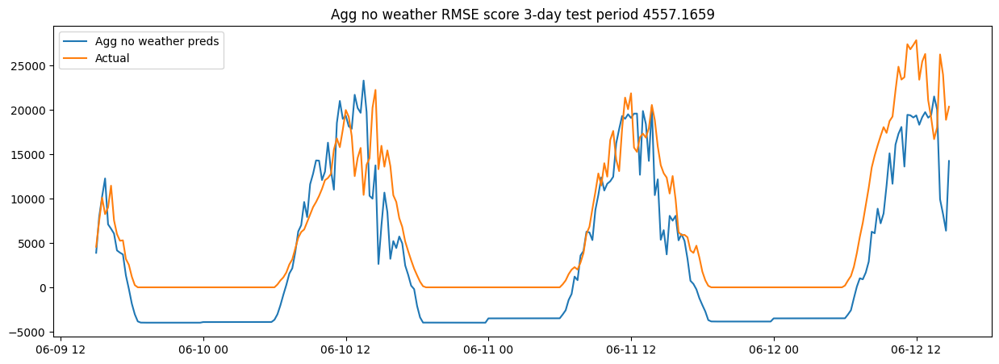

In [ ]:
fig, ax = plt.subplots(figsize=(15,5))
# plt.plot(X[X.index > '2020-06-10'].index, y_pred[X.index > '2020-06-10'], alpha=0.5)
plt.plot(df_agg_test.index, np.array(agg_no_weather_preds), label='agg')
plt.plot(target_test.index, np.array(target_test));
plt.title(f'Agg no weather RMSE score 3-day test period {agg_no_weather_score}')
plt.legend(['Agg no weather preds', 'Actual']);


Let's streamline this a bit and make a function since we will be training our model several times. I'll comment more once each scenario has run.

In [ ]:
def model_train_plot(df_train, df_test, target_train, target_test,
                     name, results = {}, cv_indices = cv_indices,
                     param_grid = {}, estimator=XGBRegressor(random_state=1)):
    try:
        best_rmse_score_test = results['best_rmse_score_test']
        best_rmse_score_cv = results['best_rmse_score_cv']
        best_std_cv = results['best_std_cv']
    except:
        pass

    gs = GridSearchCV(xgb,
                      param_grid=param_grid,
                      cv=cv_indices,
                      scoring='neg_root_mean_squared_error',
                      verbose=0)
    gs.fit(df_train, target_train);


    params_tried = gs.param_grid
    best_params = gs.best_params_

    rmse_score_cv = -np.round(gs.best_score_, 4)
    results.update({'rmse_score_cv':rmse_score_cv})

    std_cv = np.round(gs.cv_results_['std_test_score'][0], 4)
    results.update({'std_cv':std_cv})

    best_estimator = gs.best_estimator_
    feature_importances_df = pd.DataFrame(best_estimator.feature_importances_.T,
                                          index=list(best_estimator.feature_names_in_),
                                          columns=['Feature_Importance']).sort_values('Feature_Importance',
                                                                                      ascending=False)

    model_preds = best_estimator.predict(df_test)
    rmse_score_test = np.round(mean_squared_error(target_test,
                                                  model_preds,
                                                  squared=False),
                               4)
    results.update({'rmse_score_test':rmse_score_test})


    fig, ax = plt.subplots(figsize=(15,5))
    plt.plot(df_test.index, np.array(model_preds), label='agg')
    plt.plot(target_test.index, np.array(target_test));
    plt.title(f'AC Power {name}_preds vs actual')
    plt.ylabel('AC Power (kW)')
    plt.xlabel('Day')


    plt.figtext(.13, .85, s=f'RMSE Score test set: {rmse_score_test}')
    try:
        rmse_score_test_difference = np.round(rmse_score_test - best_rmse_score_test, 2)
        if (rmse_score_test_difference) < 0:
            plt.figtext(.28, .85,
                        s=f'({rmse_score_test_difference}) New Best',
                        color='green')
            results.update({'best_rmse_score_test': rmse_score_test })
        elif (rmse_score_test_difference) == 0:
            plt.figtext(.28, .85,
                        s=f'({rmse_score_test_difference})')
        elif (rmse_score_test_difference) > 0:
            plt.figtext(.28, .85,
                        s=f'(+{rmse_score_test_difference})',
                        color='red')
    except:
        results.update({'best_rmse_score_test':rmse_score_test})

    plt.figtext(.13, .82, s=f'CV RMSE Score: {rmse_score_cv}')
    try:
        rmse_score_cv_difference = np.round(rmse_score_cv - best_rmse_score_cv, 2)
        if (rmse_score_cv_difference) < 0:
            plt.figtext(.28, .82,
                        s=f'({rmse_score_cv_difference}) New Best',
                        color='green')
            results.update({'best_rmse_score_cv': rmse_score_cv })
        elif (rmse_score_cv_difference) == 0:
            plt.figtext(.28, .82,
                        s=f'({rmse_score_cv_difference})')
        elif (rmse_score_cv_difference) > 0:
            plt.figtext(.28, .82,
                        s=f'(+{rmse_score_cv_difference})',
                        color='red')
    except:
        results.update({'best_rmse_score_cv':rmse_score_cv})

    plt.figtext(.13, .79,
                s=f'CV STD: {std_cv}')
    try:
        std_cv_difference = np.round(std_cv - best_std_cv, 2)
        if (std_cv_difference) < 0:
            plt.figtext(.28, .79,
                        s=f'({std_cv_difference}) New Best',
                        color='green')
            results.update({'best_std_cv': std_cv})
        elif (std_cv_difference) == 0:
            plt.figtext(.28, .79,
                        s=f'({std_cv_difference})')
        elif (std_cv_difference) > 0:
            plt.figtext(.28, .79,
                        s=f'(+{std_cv_difference})',
                        color='red')
    except:
        results.update({'best_std_cv':std_cv})

    plt.figtext(.13, .76, s=f'Best Params: {best_params}')
    plt.legend([f'{name} preds', 'Actual'], loc='upper right');
    results.update({'best_params':best_params, 'params_tried':params_tried})
    return fig, gs, results, feature_importances_df.T, model_preds

Now that we have a training function in place let's call it with each of the four scenarios. We will also give it a basic param_grid to hopefully give each scenario a fair chance.

,AC_POWER,MINUTES_15,HOUR,TOTAL_YIELD,DAILY_YIELD,DAY_WEEK,DC_POWER,DAY
Feature_Importance,0.743895,0.09075,0.070275,0.030733,0.02894,0.01796,0.016361,0.001087


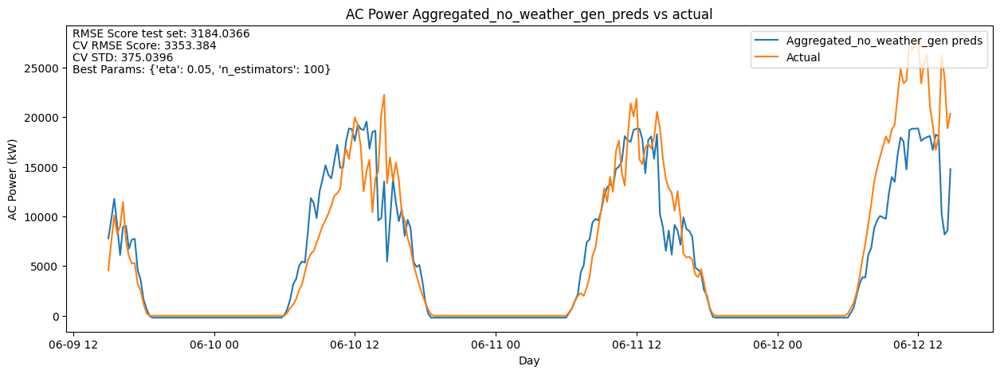

In [ ]:
param_grid = {'eta': [0.05, 0.1, 0.3], 'n_estimators': [50, 100, 150]}
fig, gs_agg_no_weather, results, feat, preds = model_train_plot(df_agg_no_weather_train, df_agg_no_weather_test,
                                                                target_train, target_test,
                                                                'Aggregated_no_weather_gen',
                                                                results={},
                                                                param_grid=param_grid)
feat


,AC_POWER,MINUTES_15,HOUR,DC_POWER,DAILY_YIELD,TOTAL_YIELD,DAY_WEEK,MODULE_TEMPERATURE,AMBIENT_TEMPERATURE,IRRADIATION,DAY
Feature_Importance,0.715359,0.073127,0.06211,0.051591,0.024923,0.023518,0.016293,0.013985,0.012849,0.005982,0.000262


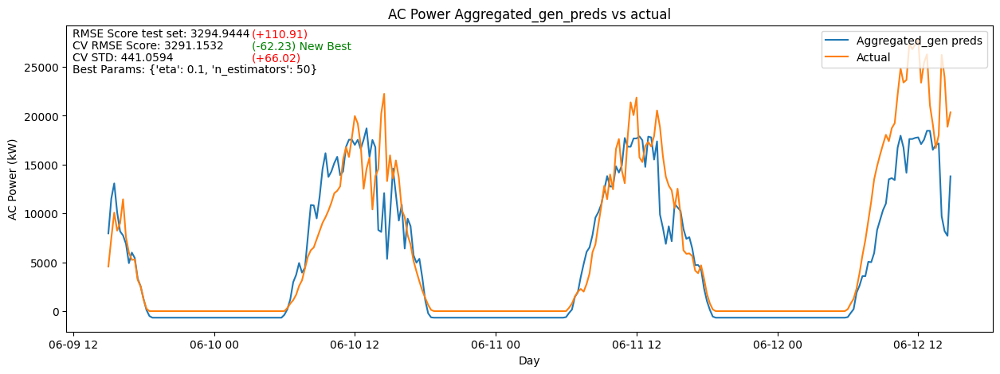

In [ ]:
fig, gs_agg, results, feat, preds = model_train_plot(df_agg_train, df_agg_test,
                                                     target_train, target_test,
                                                     'Aggregated_gen',
                                                     results=results, param_grid=param_grid)
feat

,AC_POWER_INVERTER_6,DC_POWER_INVERTER_16,AC_POWER_INVERTER_17,AC_POWER_INVERTER_7,DC_POWER_INVERTER_19,AC_POWER_INVERTER_10,AC_POWER_INVERTER_14,AC_POWER_INVERTER_21,AC_POWER_INVERTER_9,DAILY_YIELD_INVERTER_10,...,TOTAL_YIELD_INVERTER_17,DC_POWER_INVERTER_7,TOTAL_YIELD_INVERTER_5,TOTAL_YIELD_INVERTER_6,TOTAL_YIELD_INVERTER_18,DC_POWER_INVERTER_11,TOTAL_YIELD_INVERTER_13,DC_POWER_INVERTER_6,TOTAL_YIELD_INVERTER_19,DC_POWER_INVERTER_20
Feature_Importance,0.324404,0.199013,0.189804,0.087604,0.046136,0.012203,0.011784,0.00958,0.009239,0.007577,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


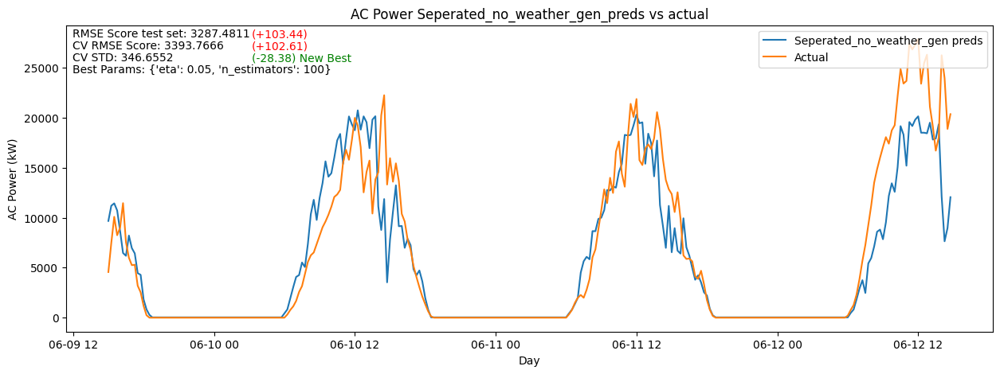

In [ ]:
fig, gs_sep_no_weather, results, feat, pred = model_train_plot(df_sep_no_weather_train, df_sep_no_weather_test,
                                                               target_train, target_test,
                                                               'Seperated_no_weather_gen',
                                                               results=results,
                                                               param_grid=param_grid)
feat

,AC_POWER_INVERTER_7,AC_POWER_INVERTER_6,DC_POWER_INVERTER_16,AC_POWER_INVERTER_17,DC_POWER_INVERTER_19,AC_POWER_INVERTER_10,AC_POWER_INVERTER_14,DAILY_YIELD_INVERTER_10,AC_POWER_INVERTER_9,DC_POWER_INVERTER_14,...,DC_POWER_INVERTER_17,TOTAL_YIELD_INVERTER_5,TOTAL_YIELD_INVERTER_17,TOTAL_YIELD_INVERTER_11,DC_POWER_INVERTER_18,DC_POWER_INVERTER_11,TOTAL_YIELD_INVERTER_18,TOTAL_YIELD_INVERTER_10,TOTAL_YIELD_INVERTER_4,TOTAL_YIELD_INVERTER_19
Feature_Importance,0.215215,0.215122,0.193966,0.184679,0.031404,0.019256,0.018672,0.013015,0.007786,0.007524,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


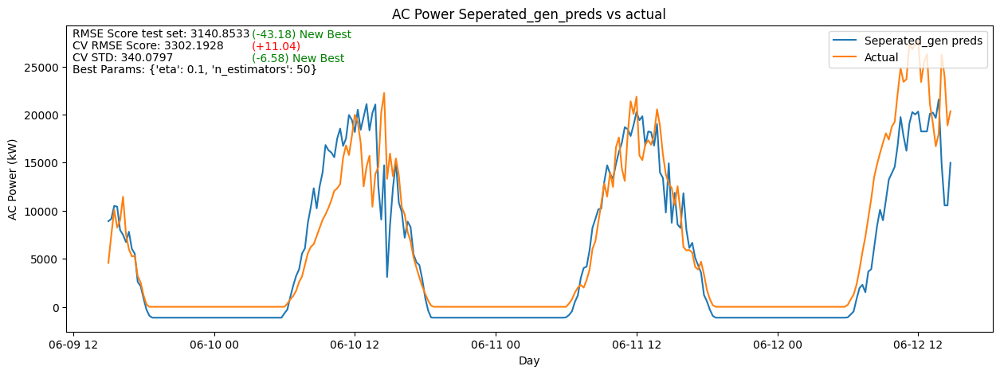

In [ ]:
fig, gs_sep, results, feat, preds = model_train_plot(df_sep_train, df_sep_test,
                                                     target_train, target_test,
                                                     'Seperated_gen',
                                                     results=results, param_grid=param_grid)
feat

All of scenarios outperform the baseline on the 3-day test period. The scenarios with the inverters separated do a bit better with the 3-day test period, but worse with the CV RSME score. To hopefully get a more robust model and not one that just performs well on our 3-day test period, let's prioritize the CV results. At the same time, we shouldn't totally discount the 3-day test period, since this is what we will ultimately compare with the deep learning model. Let's go with the aggregated generation data that includes the weather data as a nice balance of these two. Also, since it is one of the simpler scenarios it will be quicker to train and gives us more bandwidth to engineer additional features.


# **Feature Engineering**

Now that we have an idea of how the model is performing with just some basic datetime features, let's see how we can improve the performance with adding additional features.

# **SIN/COS features**
First, we'll make a cosine and sine representation of the day. This technique was taken from this time series tutorial. It should help the model pick out the clear daily pattern.

In [ ]:
#just using the selected dataset that doesn't include weather or separate generation data for each inverter
timestamp_s = df_agg.index.map(pd.Timestamp.timestamp)
day_s = 24*60*60
df_agg['Day_sin'] = np.sin(timestamp_s  * (2 * np.pi / day_s))
df_agg['Day_cos'] = np.cos(timestamp_s * (2 * np.pi / day_s))


#respliting with new features
df_agg_train = df_agg.iloc[:-day*4]
df_agg_test = df_agg.iloc[-day*4:-day]

Let's try our model again with this added feature. We will use the best params from the grid search as well.

,Day_cos,TOTAL_YIELD,MINUTES_15,DAY_WEEK,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,DAILY_YIELD,IRRADIATION,DC_POWER,HOUR,DAY,Day_sin
Feature_Importance,0.931835,0.010989,0.009439,0.00917,0.007131,0.006858,0.006716,0.005959,0.004803,0.00384,0.001941,0.000969,0.00035


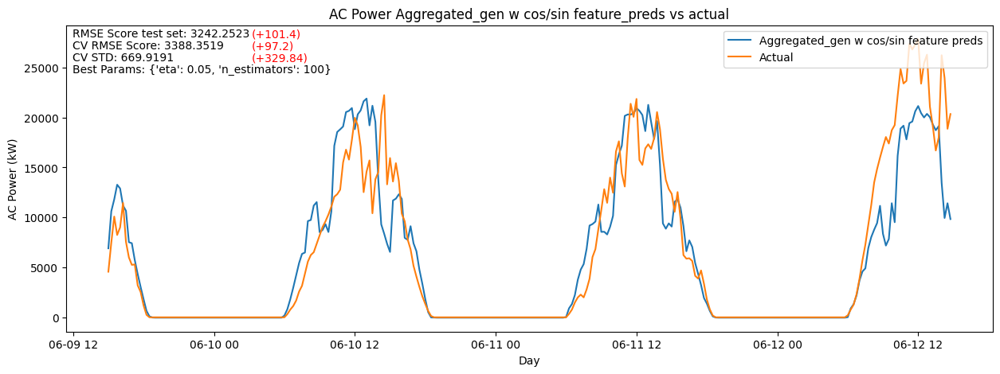

In [ ]:
param_grid = {'eta': [0.05], 'n_estimators': [100]}
fig, gs_agg, results, feat, model_preds = model_train_plot(df_agg_train, df_agg_test,
                                                           target_train,  target_test,
                                                           name='Aggregated_gen w cos/sin feature',
                                                           results=results, param_grid=param_grid)
feat

Already some improvement in the CV score and it is by far the most important feature! The cosine tracks much better with our target (see below), so has more importance. Removing the sine feature though does increase the score slightly, so we will leave it in for now.

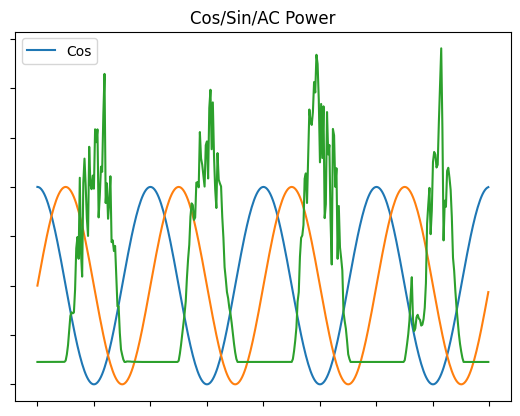

In [ ]:
fig = plt.subplot()
sns.lineplot(df_agg['Day_cos'].iloc[:4*day])
sns.lineplot(df_agg['Day_sin'].iloc[:4*day])
sns.lineplot((df_agg['AC_POWER'].iloc[:4*day] - df_agg['AC_POWER'].mean())/ df_agg['AC_POWER'].std())
fig.set_ylabel('')
fig.set_xlabel('')
fig.set_yticklabels('')
fig.set_xticklabels('')
fig.legend(['Cos'])
plt.title('Cos/Sin/AC Power');

This shows how cosine does a better job of tracking with the AC power. Let's generalize the cos/sin features some and add some more frequencies to see if we can pick up on additional trends.

In [ ]:
def day_cos_sin(df, freq=1, type='both'):
    timestamp_s = df.index.map(pd.Timestamp.timestamp)
    day_s = 24*60*60
    if type=='both':
        df[f'Day_sin_{freq}'] = np.sin(timestamp_s  * (2 * freq * np.pi / day_s))
        df[f'Day_cos_{freq}'] = np.cos(timestamp_s * (2 * freq * np.pi / day_s))
    elif type=='cos':
        df[f'Day_cos_{freq}'] = np.cos(timestamp_s * (2 * freq * np.pi / day_s))
    elif type=='sin':
        df[f'Day_sin_{freq}'] = np.sin(timestamp_s  * (2 * freq * np.pi / day_s))
    return df

#We will just add cos features and go up to a 'week'
df_agg = day_cos_sin(df_agg, .5, type='both')
df_agg = day_cos_sin(df_agg, 2, type='both')
df_agg = day_cos_sin(df_agg, 3, type='both')
df_agg = day_cos_sin(df_agg, 4, type='both')
df_agg = day_cos_sin(df_agg, 5, type='both')
df_agg = day_cos_sin(df_agg, 6, type='both')
df_agg = day_cos_sin(df_agg, 7, type='both')

#respliting with new features
df_agg_train = df_agg.iloc[:-day*4]
df_agg_test = df_agg.iloc[-day*4:-day]

,Day_cos,Day_cos_3,Day_cos_2,Day_cos_4,TOTAL_YIELD,DAY_WEEK,AC_POWER,Day_sin_4,Day_sin_2,MINUTES_15,...,Day_sin_7,Day_sin_0.5,HOUR,IRRADIATION,DC_POWER,Day_cos_7,Day_sin_6,Day_cos_5,DAY,Day_sin
Feature_Importance,0.658805,0.19637,0.072108,0.009935,0.004392,0.004365,0.004283,0.004122,0.004005,0.003745,...,0.002579,0.002508,0.002285,0.002231,0.001943,0.00176,0.00143,0.001038,0.00013,0.000048


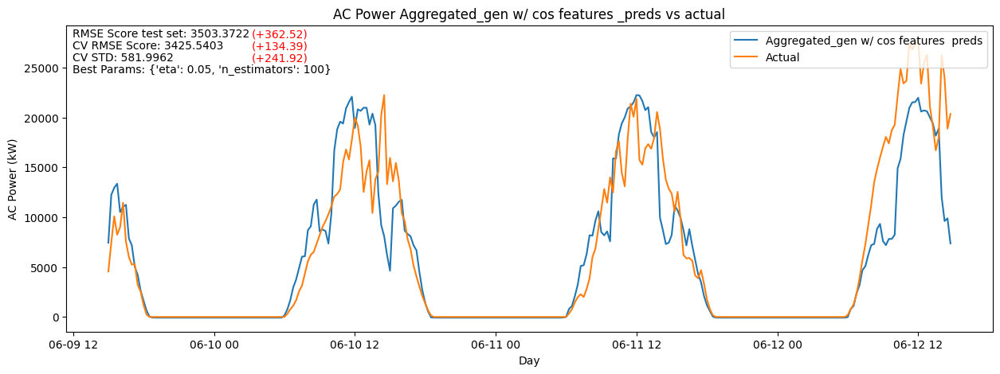

In [ ]:
param_grid = {'eta': [0.05], 'n_estimators': [100]}
fig, gs_agg, results, feat, model_preds = model_train_plot(df_agg_train, df_agg_test,
                                                           target_train, target_test,
                                                           'Aggregated_gen w/ cos features ',
                                                           results=results, param_grid=param_grid)
feat

The cosine features over 1-4 days seem somewhat helpful, but not as much after that. This suggests that our data has useful information up to a period of 4 days. Let's remove the cosine features beyond 4 days and the half-day feature (0.5 frequency).

,Day_cos,Day_cos_3,Day_cos_2,Day_cos_4,TOTAL_YIELD,DAY_WEEK,MINUTES_15,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,DAILY_YIELD,IRRADIATION,HOUR,DAY,DC_POWER
Feature_Importance,0.630941,0.234056,0.077221,0.012832,0.006924,0.006216,0.006032,0.004642,0.004302,0.004151,0.003684,0.002927,0.002289,0.00193,0.001854


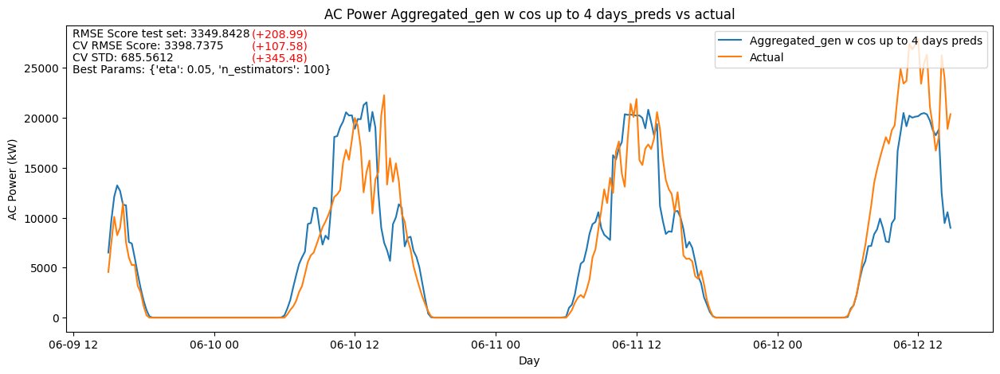

In [ ]:
df_agg = df_agg.drop(['Day_sin_0.5', 'Day_sin', 'Day_sin_2', 'Day_sin_3',
                      'Day_sin_4', 'Day_sin_5', 'Day_sin_6', 'Day_sin_7',
                      'Day_cos_6', 'Day_cos_7', 'Day_cos_0.5', 'Day_cos_5',
                      'Day_cos_6', 'Day_cos_7'],
                     axis=1)

#respliting with new features
df_agg_train = df_agg.iloc[:-day*4]
df_agg_test = df_agg.iloc[-day*4:-day]

param_grid = {'eta': [0.05], 'n_estimators': [100]}
fig, gs_agg, results, feat, model_preds = model_train_plot(df_agg_train, df_agg_test,
                                                           target_train, target_test,
                                                           'Aggregated_gen w cos up to 4 days',
                                                           results=results, param_grid=param_grid)
feat

Lag, rolling, and decomposition features
Not much help, but we at least got the best CV RMSE score. Now will add a few more kinds of features. We'll focus these in on the generation and weather data ignoring the datetime features. Let's start with a lag feature. Since our cosine features were picking up some potentially useful information up to a 4-day period, we'll make a lag feature going back 4 days. This will introduce some nulls for these features at the beginning of the dataset as we shift the lag features forward, but our model should be able to handle them

,Day_cos,Day_cos_3,Day_cos_2,lag_15DC_POWER3,Day_cos_4,lag_dayTOTAL_YIELD192,lag_15DAILY_YIELD2,lag_dayDAILY_YIELD192,lag_60AMBIENT_TEMPERATURE12,lag_60AMBIENT_TEMPERATURE8,...,lag_60DAILY_YIELD0,lag_60DAILY_YIELD4,lag_15AMBIENT_TEMPERATURE0,lag_60TOTAL_YIELD0,lag_60TOTAL_YIELD4,lag_30AC_POWER0,lag_60AMBIENT_TEMPERATURE0,lag_60AMBIENT_TEMPERATURE4,lag_15TOTAL_YIELD1,lag_30MODULE_TEMPERATURE0
Feature_Importance,0.601075,0.141826,0.061856,0.017122,0.012069,0.009996,0.006998,0.006344,0.005791,0.005134,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


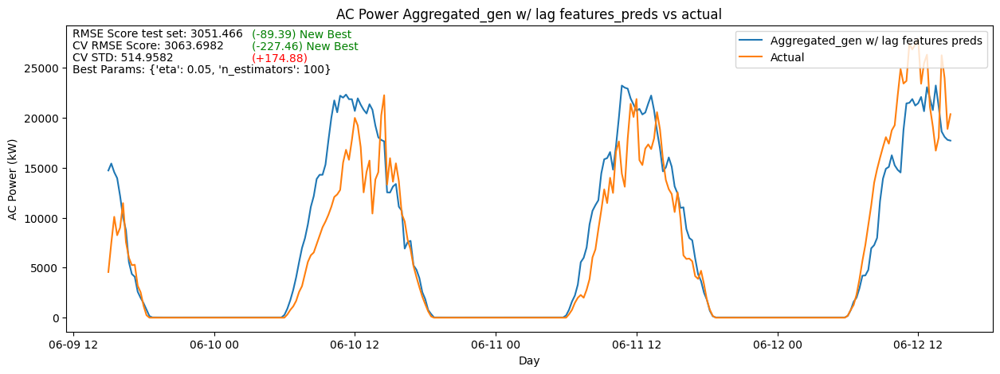

In [ ]:
new_features = [df_agg]
for f in all_features:
    for i in range(0, 4, 1):
        lag_feature= df_agg[f].shift(i)
        lag_feature.name = f'lag_15{f}{i}'
        new_features.append(lag_feature)


for f in all_features:
    for i in range(0, 8, 2):
        lag_feature= df_agg[f].shift(i)
        lag_feature.name = f'lag_30{f}{i}'
        new_features.append(lag_feature)


for f in all_features:
    for i in range(0, 16, 4):
        lag_feature= df_agg[f].shift(i)
        lag_feature.name = f'lag_60{f}{i}'
        new_features.append(lag_feature)

for f in all_features:
    for i in range(0, 4*day, day):
        lag_feature= df_agg[f].shift(i)
        lag_feature.name = f'lag_day{f}{i}'
        new_features.append(lag_feature)

df_agg = pd.concat(new_features, axis=1)

#respliting with new features
df_agg_train = df_agg.iloc[:-day*4]
df_agg_test = df_agg.iloc[-day*4:-day]

#retraining with new features
param_grid = {'eta': [0.05], 'n_estimators': [100]}
fig, gs_agg, results, feat, model_preds = model_train_plot(df_agg_train, df_agg_test,
                                                           target_train, target_test,
                                                           name='Aggregated_gen w/ lag features',
                                                           results=results, param_grid=param_grid)
feat

Definitely a noticeable improvement. Based on the feature importance the lags of a day or more were the most helpful. Now we'll add some rolling features and features based on our previous decomposition of the target. This should give our model a smoother picture of the previous generation data to work with; similar to when we resampled the target to hourly and it removed much of the noise.

,SEASONAL,Day_cos,Day_cos_3,Day_cos_2,lag_dayTOTAL_YIELD192,rolling_DAILY_YIELD_day_3,RESIDUAL,rolling_IRRADIATION,rolling_DC_POWER_day_3,rolling_TOTAL_YIELD_day_4,...,lag_dayMODULE_TEMPERATURE0,lag_15DAILY_YIELD0,lag_60DC_POWER12,lag_60DC_POWER8,lag_dayIRRADIATION0,lag_60DC_POWER4,lag_60AMBIENT_TEMPERATURE0,lag_15DC_POWER3,rolling_DC_POWER,lag_30DAILY_YIELD2
Feature_Importance,0.319385,0.303695,0.116221,0.063573,0.016772,0.014352,0.013737,0.013387,0.010854,0.00776,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


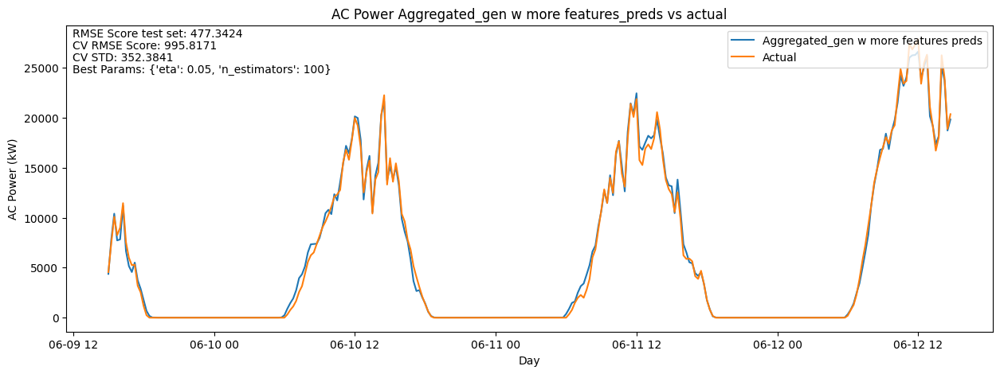

In [ ]:
df_agg = df_agg.copy()

new_features = [df_agg]
for f in all_features:
    lag_feature= df_agg[f].rolling(4).mean()
    lag_feature.name = f'rolling_{f}'
    new_features.append(lag_feature)


for f in all_features:
    lag_feature= df_agg[f].shift(day).rolling(5, center=True).mean()
    lag_feature.name = f'rolling_{f}_day'
    new_features.append(lag_feature)


for f in all_features:
    lag_feature= df_agg[f].shift(2*day).rolling(5, center=True).mean()
    lag_feature.name = f'rolling_{f}_day_2'
    new_features.append(lag_feature)


for f in all_features:
    lag_feature= df_agg[f].shift(3*day).rolling(5, center=True).mean()
    lag_feature.name = f'rolling_{f}_day_3'
    new_features.append(lag_feature)
    df_agg = pd.concat(new_features, axis=1)

for f in all_features:
    lag_feature= df_agg[f].shift(4*day).rolling(5, center=True).mean()
    lag_feature.name = f'rolling_{f}_day_4'
    new_features.append(lag_feature)

df_agg = pd.concat(new_features, axis=1)

#Decomposition features
df_agg['TREND'] = result_decompose.trend
df_agg['SEASONAL'] = result_decompose.seasonal
df_agg['RESIDUAL'] = result_decompose.resid

#respliting with new features
df_agg_train = df_agg.iloc[:-day*4]
df_agg_test = df_agg.iloc[-day*4:-day]

#retraining with new features
param_grid = {'eta': [0.05], 'n_estimators': [100]}
fig, gs_agg, results_decomp, feat, model_preds= model_train_plot(df_agg_train, df_agg_test,
                                                                 target_train, target_test,
                                                                 'Aggregated_gen w more features',
                                                                 results= {}, param_grid=param_grid,
                                                                 cv_indices=cv_indices)
feat

Too good to be true?
Yes, definitely! After a quick investigation, it appears target leakage is making the results seem much better than they really are. Our culprit is the decomposition features, which are based on the target. But they still could be helpful. Let's try again with them based on AC Power, but not including the day ahead information from the target. Setting the two-sided parameter to False in the seasonal_decompose function is also important to avoid target leakage as it only includes past data when calculating the moving average.

,Day_cos,SEASONAL,Day_cos_3,Day_cos_2,rolling_AC_POWER,Day_cos_4,lag_dayTOTAL_YIELD192,rolling_DAILY_YIELD_day_2,lag_15DC_POWER3,rolling_TOTAL_YIELD_day_4,...,lag_30TOTAL_YIELD0,lag_30AMBIENT_TEMPERATURE2,lag_30TOTAL_YIELD2,lag_dayDAILY_YIELD0,lag_dayDC_POWER288,lag_dayDC_POWER192,lag_30TOTAL_YIELD6,lag_dayDC_POWER0,lag_30AMBIENT_TEMPERATURE0,lag_30DC_POWER4
Feature_Importance,0.334536,0.265365,0.152962,0.054554,0.012002,0.009586,0.007771,0.005883,0.005638,0.005276,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


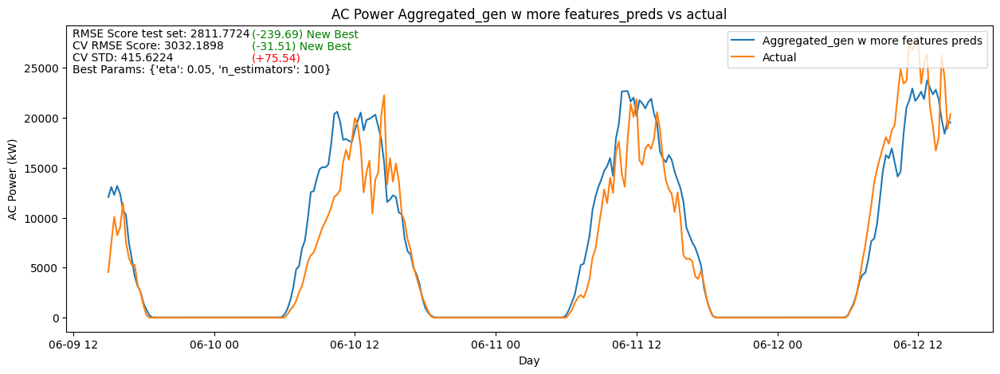

In [ ]:
result_decompose=seasonal_decompose(df_agg.AC_POWER,
                                    model='additive',
                                    period=96*7,
                                    two_sided=False);
df_agg['TREND'] = result_decompose.trend
df_agg['SEASONAL'] = result_decompose.seasonal
df_agg['RESIDUAL'] = result_decompose.resid

#respliting with new features
df_agg_train = df_agg.iloc[:-day*4]
df_agg_test = df_agg.iloc[-day*4:-day]

#retraining with new features
param_grid = {'eta': [0.05], 'n_estimators': [100]}
fig, gs_agg, results, feat, model_preds= model_train_plot(df_agg_train, df_agg_test,
                                                          target_train, target_test,
                                                          'Aggregated_gen w more features',
                                                          results=results, param_grid=param_grid,
                                                          cv_indices=cv_indices)
feat

Perhaps some performance gains, but it is hard to tell for sure as our test period got a fair bit worse. We might have too many features now and/or need to retune the parameters to account for the additional features the model has to process. Let's start with retuning the parameters.

Tuning parameters
Let's do a few rounds of gridsearch including some additional parameters to see if we can improve the performance.

"""1st params tried param_grid = {'booster' : ['dart', 'gbtree'],
                                'n_estimators': [50, 100, 150],
                                'eta': [0.01, 0.5, 0.1] }
#best params {'booster' : ['gbtree'],
                'n_estimators': [100],
                'eta': [0.1] }
# Additional parameters
# 2nd param_grid tried param_grid= {'booster' : ['gbtree'],
                                    'max_depth': [3, 5, 10],
                                    'colsample_bytree': [0.5, 0.75, 1],
                                    'subsample': [0.6, 0.8, 1],
                                    'n_estimators' : [100],
                                    'eta' : [0.1]}
#best params {'booster' : ['gbtree'],
                'max_depth':  [3],
                'colsample_bytree': [1],
                'subsample': [0.8],
                'n_estimators' : [100],
                'eta' : [0.1]}
#3rd param_grid tried param_grid = {'booster' : ['gbtree'],
                                    'max_depth': [1, 2, 3],
                                    'colsample_bytree': [1],
                                    'subsample': [0.8],
                                    'n_estimators': [100],
                                    'eta': [0.1]}
#best params {'booster' : ['gbtree'],
                'max_depth': [1],
                'colsample_bytree': [1],
                'subsample': [0.8],
                'n_estimators': [100],
                'eta': [0.1]}
#4th param_grid tried param_grid = {'booster' : ['gbtree'],
                                    'max_depth': [1],
                                    'colsample_bytree': [1],
                                    'subsample': [0.8],
                                    'n_estimators': [75, 100, 125],
                                    'eta': [0.075, 0.1, 0.125]}
#best params {'booster' : ['gbtree'],
                'max_depth': [1],
                'colsample_bytree': [1],
                'subsample': [0.8],
                'n_estimators': [75],
                'eta': [0.075]}
#5th tried param_grid = {'booster' : ['gbtree'],
                            'max_depth': [1],
                            'colsample_bytree': [1],
                            'subsample': [0.8],
                            'n_estimators': [70, 75, 80],
                            'eta': [0.065, 0.075, 0.085]}
"""
param_grid = {'booster' : ['gbtree'], 'max_depth': [1], 'colsample_bytree': [1],
              'subsample': [0.8], 'n_estimators': [70], 'eta': [0.065]}
fig, gs_agg, results, feat, model_preds = model_train_plot(df_agg_train, df_agg_test,
                                                           target_train, target_test,
                                                           'Aggregated_gen tune',
                                                           results=results, param_grid=param_grid)
feat
Day_cos

There is a pretty big gain in performance here. Setting the max depth to 1, the model becomes a much simpler and it is less likely to find every peak or valley, but on the average does a decent job. Depending on the exact application this could be underfitting, but since it works well with our chosen metric, we'll stick with it.

Feature selection with Random Forest
To simplify our model even further and see if we can help it focus in on the more important features, let's use a random forest to filter out some of the less helpful features.

,Day_cos,SEASONAL,Day_cos_3,Day_cos_2,lag_dayTOTAL_YIELD192,lag_dayDAILY_YIELD192,Day_cos_4,rolling_AC_POWER,rolling_TOTAL_YIELD_day_4,rolling_IRRADIATION_day_3,...,lag_15MODULE_TEMPERATURE0,lag_60DAILY_YIELD0,lag_dayMODULE_TEMPERATURE0,lag_60DC_POWER8,lag_60DC_POWER4,lag_15AMBIENT_TEMPERATURE0,lag_dayIRRADIATION0,lag_60DC_POWER0,lag_15TOTAL_YIELD1,lag_30DAILY_YIELD2
Feature_Importance,0.582155,0.224114,0.054187,0.03107,0.010966,0.004816,0.004531,0.004393,0.004106,0.003769,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


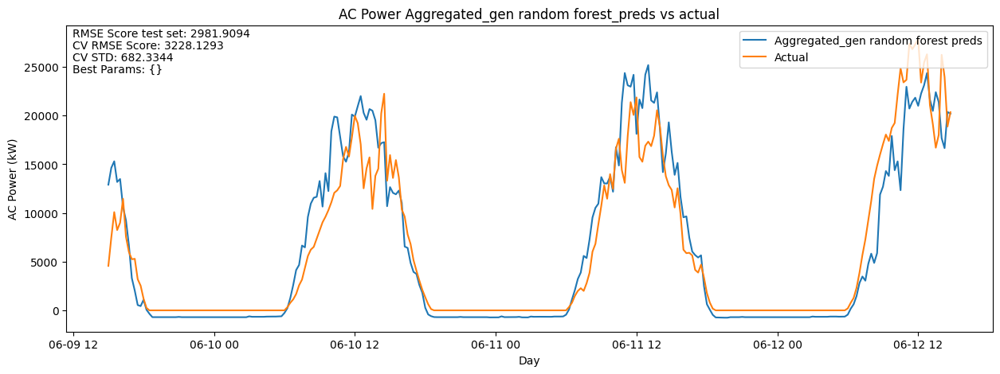

In [ ]:
rfc = RandomForestRegressor(random_state=1)
fig, gs_agg, results_tree, feat, model_preds = model_train_plot(df_agg_train, df_agg_test,
                                                                target_train, target_test,
                                                                'Aggregated_gen random forest',
                                                                estimator=rfc, param_grid={})
feat

,SEASONAL,Day_cos,lag_dayTOTAL_YIELD192,Day_cos_2,Day_cos_3
Feature_Importance,0.504538,0.483699,0.011763,0.0,0.0


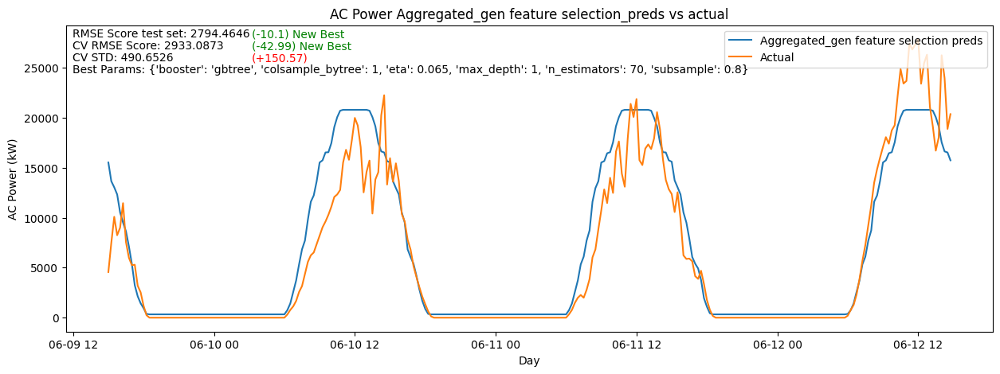

In [ ]:
model = SelectFromModel(gs_agg.best_estimator_, prefit=True, threshold=0.005)

df_agg_new = pd.DataFrame(model.transform(df_agg),
                          columns=model.get_feature_names_out(df_agg.columns),
                          index=df_agg.index)

df_agg_train = df_agg_new.iloc[:-day*4]
df_agg_test = df_agg_new.iloc[-day*4:-day]

param_grid = param_grid = {'booster' : ['gbtree'],
                           'max_depth': [1],
                           'colsample_bytree': [1],
                           'subsample': [0.8],
                           'n_estimators': [70],
                           'eta': [0.065]}
fig, gs_agg, results, feat, model_preds = model_train_plot(df_agg_train, df_agg_test,
                                                           target_train, target_test,
                                                           'Aggregated_gen feature selection',
                                                           results=results, param_grid=param_grid)
feat

Now our model is even simpler and scoring better. Also, Day_cos_2, Day_cos_3 and rolling_DAILY_YIELD_day_2 are safe to remove since they don't have any importance in our model. Let's remove a few more features and see if we can improve the score just a bit more.

,Day_cos,rolling_AC_POWER,lag_dayTOTAL_YIELD192
Feature_Importance,0.706458,0.278258,0.015284


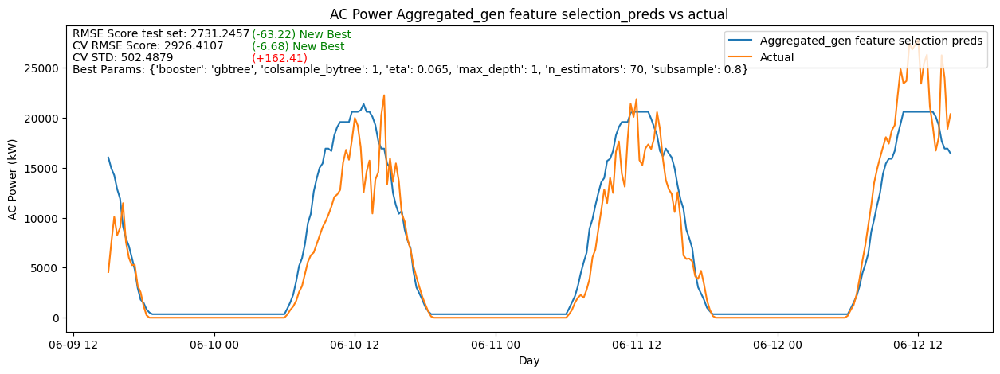

In [ ]:
df_agg_train = df_agg[['Day_cos', 'rolling_AC_POWER', 'lag_dayTOTAL_YIELD192']].iloc[:-day*4]
df_agg_test = df_agg[['Day_cos', 'rolling_AC_POWER', 'lag_dayTOTAL_YIELD192']].iloc[-day*4:-day]

param_grid = param_grid = {'booster' : ['gbtree'],
                           'max_depth': [1],
                           'colsample_bytree': [1],
                           'subsample': [0.8],
                           'n_estimators': [70],
                           'eta': [0.065]}
fig, gs_agg, results, feat, model_preds = model_train_plot(df_agg_train, df_agg_test,
                                                           target_train, target_test,
                                                           'Aggregated_gen feature selection',
                                                           results=results, param_grid=param_grid)
feat


Although, there is always room for further tuning we will stick with this as our best XGBoost model with a RMSE score of 2926 kW on the 3 day test period.

Onto Deep learning
Now that we have completed our XGBoost model, let's move to our deep learning model. For our deep learning model, we will use a LSTM layer to make a recurrent neural network model (RNN). This should allow our model to store helpful information about that past to use for its forecast. It will take in the data from the last 4 days and generate a forecast of AC Power for each 15-minute interval for the next day.

Most of the preprocessing has already been finished before, but for our model to work, we additionally need to normalize the input data. We'll again check to see how it performs using the inverters separated and aggregated, including the weather data in both. My guess is that our deep learning model might be able to make better use of the additional features and show some improvement with the inverters separated. First, we have to setup the data to feed into our deep learning model.

In [ ]:
#removing features (besides basic datetime ones)
df_agg = df_agg_dl
df_sep = df_sep_dl
day = 96
tscv = TimeSeriesSplit(test_size=day, n_splits=12, max_train_size=2*day)
cv_indices = []
#since all our inverter splits share the same index we'll just choose df_agg
for train_indices, test_indices in tscv.split(df_agg.iloc[:-day*2]):
    cv_indices.append((train_indices, test_indices))

In [ ]:
import tensorflow as tf

### df_sep full data including weather
inputs_sep_trains = []
labels_sep_trains = []
for i in range(3, len(cv_indices)-4):
    input_sep_train = (df_sep.iloc[cv_indices[i][0]] - df_sep.iloc[cv_indices[i][0]].mean()) \
                       / df_sep.iloc[cv_indices[i][0]].std()
    label_sep_train = (target.iloc[cv_indices[i][1]] - target.iloc[cv_indices[i][1]].mean()) \
                       / target.iloc[cv_indices[i][1]].std()
    label_sep_train = pd.DataFrame(label_sep_train, columns=['AC_POWER'])
    inputs_sep_trains.append(input_sep_train)
    labels_sep_trains.append(label_sep_train)

inputs_sep_train_stack = tf.stack(inputs_sep_trains)
labels_sep_train_stack = tf.stack(labels_sep_trains)

inputs_sep_vals = []
labels_sep_vals = []
for i in range(len(cv_indices)-4 , len(cv_indices)):
    input_sep_val = (df_sep.iloc[cv_indices[i][0]] - df_sep.iloc[cv_indices[i][0]].mean()) \
                     / df_sep.iloc[cv_indices[i][0]].std()
    label_sep_val = (target.iloc[cv_indices[i][1]] - target.iloc[cv_indices[i][1]].mean()) \
                     / target.iloc[cv_indices[i][1]].std()
    label_sep_val = pd.DataFrame(label_sep_val, columns=['AC_POWER'])
    inputs_sep_vals.append(input_sep_val)
    labels_sep_vals.append(label_sep_val)

inputs_sep_val_stack = tf.stack(inputs_sep_vals)
labels_sep_val_stack = tf.stack(labels_sep_vals)

val = (inputs_sep_val_stack, labels_sep_val_stack)

Now that our inputs and labels are ready, we can setup and train our model. This setup is based on a model used in this tensorflow time series tutorial. We have it setup from above to take in 4 days’ worth of data at a time. It uses a multi-output, which means that it predicts the entire day ahead forecast at once; one for each 15-minute interval for a total of 96 predictions for each batch of inputs. Having return_sequence set to False in LSTM layer enables this multi-output framework.

In [ ]:
### Multi output sep
MAX_EPOCHS = 2000

sep_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(16, return_sequences=False),
    tf.keras.layers.Dense(96*1,
                          kernel_initializer=tf.initializers.zeros()),
    tf.keras.layers.Reshape([96, 1])
])

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=20,
                                                    mode='min',
                                                    restore_best_weights=True)

sep_model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=[tf.keras.metrics.RootMeanSquaredError()])

history = sep_model.fit(x=inputs_sep_train_stack, y=labels_sep_train_stack, epochs=MAX_EPOCHS,
                    validation_data=val,
                    callbacks=[early_stopping],
                    verbose=0);

1/1 [==============================] - 1s 546ms/step


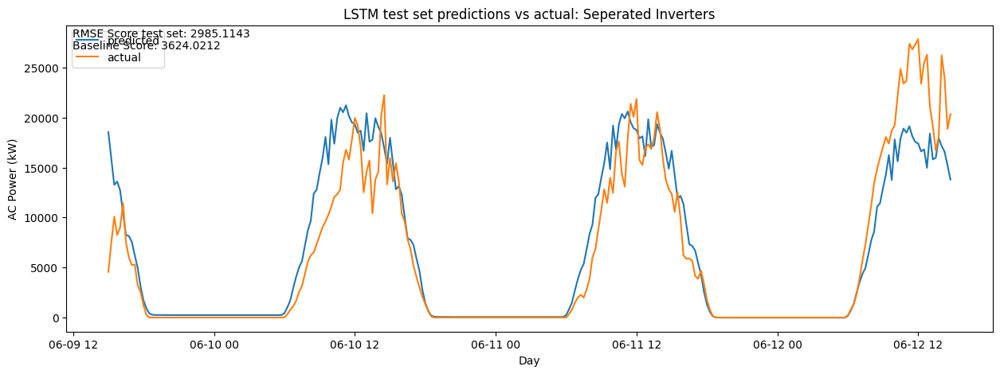

In [ ]:
day_1_labels = target.iloc[-day*3:-day*2]
day_2_labels = target.iloc[-day*2:-day*1]
day_3_labels = target.iloc[-day:]

test_labels = [day_1_labels, day_2_labels, day_3_labels]
test_labels_stack = tf.stack(test_labels)

day_1_inputs = (df_sep.iloc[-day*7:-day*3] - df_sep.iloc[-day*7:-day*3].mean()) \
                / df_sep.iloc[-day*7:-day*3].std()
day_2_inputs = (df_sep.iloc[-day*6:-day*2] - df_sep.iloc[-day*6:-day*2].mean()) \
                / df_sep.iloc[-day*6:-day*2].std()
day_3_inputs = (df_sep.iloc[-day*5:-day] - df_sep.iloc[-day*5:-day].mean()) \
                / df_sep.iloc[-day*5:-day].std()

test_inputs = [day_1_inputs, day_2_inputs, day_3_inputs]
test_inputs_stack = tf.stack(test_inputs)

target_norm_preds = sep_model.predict(test_inputs_stack)

labels_preds_day_1 = target_norm_preds[0] * df_sep.iloc[-day*7:-day*3].AC_POWER.std() \
                     + df_sep.iloc[-day*7:-day*3].AC_POWER.mean()
labels_preds_day_2 = target_norm_preds[1] * df_sep.iloc[-day*6:-day*2].AC_POWER.std() \
                     + df_sep.iloc[-day*6:-day*2].AC_POWER.mean()
labels_preds_day_3 = target_norm_preds[2] * df_sep.iloc[-day*5:-day].AC_POWER.std() \
                     + df_sep.iloc[-day*5:-day].AC_POWER.mean()

day_1_error = mean_squared_error(test_labels_stack[0],
                                 labels_preds_day_1,
                                 squared=False)
day_2_error = mean_squared_error(test_labels_stack[1],
                                 labels_preds_day_2,
                                 squared=False)
day_3_error = mean_squared_error(test_labels_stack[2],
                                 labels_preds_day_3,
                                 squared=False)
lstm_rsme_score_test_set = np.round((day_1_error + day_2_error + day_3_error) / 3, 4)

labels_preds = np.concatenate([labels_preds_day_1,
                               labels_preds_day_2,
                               labels_preds_day_3],
                              axis = None)
test_labels = np.concatenate([test_labels_stack[0],
                              test_labels_stack[1],
                              test_labels_stack[2]],
                             axis = None)

lstm_best = {'best_score':lstm_rsme_score_test_set}

fig, ax = plt.subplots(figsize=(15,5))
plt.plot(target.iloc[-3*day:].index, labels_preds)
plt.plot(target.iloc[-3*day:].index, test_labels)
plt.figtext(.13, .85, s=f'RMSE Score test set: {lstm_rsme_score_test_set}')
plt.figtext(.13, .82, s=f'Baseline Score: {baseline_score}')
plt.title('LSTM test set predictions vs actual: Seperated Inverters')
plt.legend(['predicted', 'actual'])
plt.ylabel('AC Power (kW)')
plt.xlabel('Day');

1/1 [==============================] - 0s 489ms/step


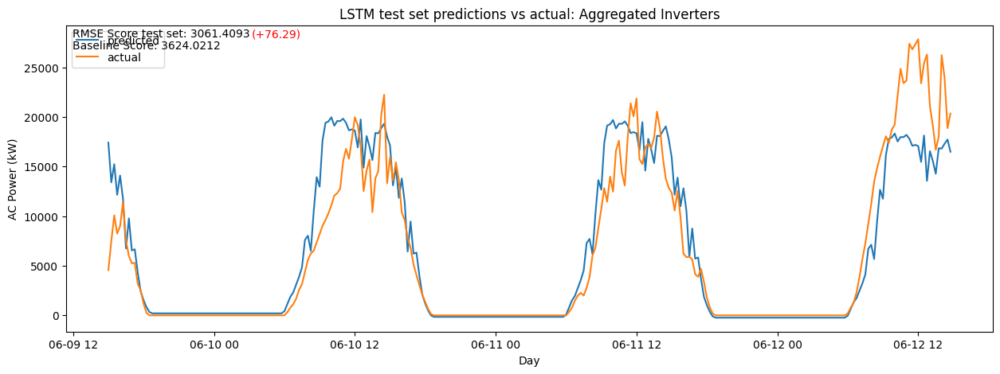

In [ ]:
### df_agg full data including weather
inputs_agg_trains = []
labels_agg_trains = []
for i in range(3, len(cv_indices)-4):
    input_agg_train = (df_agg.iloc[cv_indices[i][0]] - df_agg.iloc[cv_indices[i][0]].mean()) \
                        / df_agg.iloc[cv_indices[i][0]].std()
    label_agg_train = (target.iloc[cv_indices[i][1]] - target.iloc[cv_indices[i][1]].mean()) \
                        / target.iloc[cv_indices[i][1]].std()
    label_agg_train = pd.DataFrame(label_sep_train, columns=['AC_POWER'])
    inputs_agg_trains.append(input_agg_train)
    labels_agg_trains.append(label_agg_train)

inputs_agg_train_stack = tf.stack(inputs_agg_trains)
labels_agg_train_stack = tf.stack(labels_agg_trains)

inputs_agg_vals = []
labels_agg_vals = []
for i in range(len(cv_indices)-4 , len(cv_indices)):
    input_agg_val = (df_agg.iloc[cv_indices[i][0]] - df_agg.iloc[cv_indices[i][0]].mean()) \
                     / df_agg.iloc[cv_indices[i][0]].std()
    label_agg_val = (target.iloc[cv_indices[i][1]] - target.iloc[cv_indices[i][1]].mean()) \
                     / target.iloc[cv_indices[i][1]].std()
    label_agg_val = pd.DataFrame(label_sep_val, columns=['AC_POWER'])
    inputs_agg_vals.append(input_agg_val)
    labels_agg_vals.append(label_agg_val)

inputs_agg_val_stack = tf.stack(inputs_agg_vals)
labels_agg_val_stack = tf.stack(labels_agg_vals)

val = (inputs_agg_val_stack, labels_agg_val_stack)
### Multi output agg
MAX_EPOCHS = 2000

agg_model = tf.keras.Sequential([
    # Shape [batch, time, features] => [batch, lstm_units].
    # Adding more `lstm_units` just overfits more quickly.
    tf.keras.layers.LSTM(16, return_sequences=False),
    # Shape => [batch, out_steps*features].
    tf.keras.layers.Dense(96*1,
                          kernel_initializer=tf.initializers.zeros()),
    # Shape => [batch, out_steps, features].
    tf.keras.layers.Reshape([96, 1])
])

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=20,
                                                    mode='min',
                                                    restore_best_weights=True)

agg_model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=[tf.keras.metrics.RootMeanSquaredError()])

history = agg_model.fit(x=inputs_agg_train_stack, y=labels_agg_train_stack, epochs=MAX_EPOCHS,
                    validation_data=val,
                    callbacks=[early_stopping],
                    verbose=0);
day_1_labels = target.iloc[-day*3:-day*2]
day_2_labels = target.iloc[-day*2:-day*1]
day_3_labels = target.iloc[-day:]

test_labels = [day_1_labels, day_2_labels, day_3_labels]
test_labels_stack = tf.stack(test_labels)

day_1_inputs = (df_agg.iloc[-day*7:-day*3] - df_agg.iloc[-day*7:-day*3].mean()) \
                / df_agg.iloc[-day*7:-day*3].std()
day_2_inputs = (df_agg.iloc[-day*6:-day*2] - df_agg.iloc[-day*6:-day*2].mean()) \
                / df_agg.iloc[-day*6:-day*2].std()
day_3_inputs = (df_agg.iloc[-day*5:-day] - df_agg.iloc[-day*5:-day].mean()) \
                / df_agg.iloc[-day*5:-day].std()

test_inputs = [day_1_inputs, day_2_inputs, day_3_inputs]
test_inputs_stack = tf.stack(test_inputs)

target_norm_preds = agg_model.predict(test_inputs_stack)

labels_preds_day_1 = target_norm_preds[0] * df_agg.iloc[-day*7:-day*3].AC_POWER.std() \
                     + df_agg.iloc[-day*7:-day*3].AC_POWER.mean()
labels_preds_day_2 = target_norm_preds[1] * df_agg.iloc[-day*6:-day*2].AC_POWER.std() \
                     + df_agg.iloc[-day*6:-day*2].AC_POWER.mean()
labels_preds_day_3 = target_norm_preds[2] * df_agg.iloc[-day*5:-day].AC_POWER.std() \
                     + df_agg.iloc[-day*5:-day].AC_POWER.mean()

day_1_error = mean_squared_error(test_labels_stack[0],
                                 labels_preds_day_1,
                                 squared=False)
day_2_error = mean_squared_error(test_labels_stack[1],
                                 labels_preds_day_2,
                                 squared=False)
day_3_error = mean_squared_error(test_labels_stack[2],
                                 labels_preds_day_3,
                                 squared=False)
lstm_rsme_score_test_set = np.round((day_1_error + day_2_error + day_3_error) / 3, 4)

labels_preds = np.concatenate([labels_preds_day_1,
                               labels_preds_day_2,
                               labels_preds_day_3],
                              axis = None)
test_labels = np.concatenate([test_labels_stack[0],
                              test_labels_stack[1],
                              test_labels_stack[2]],
                             axis = None)

fig, ax = plt.subplots(figsize=(15,5))
plt.plot(target.iloc[-3*day:].index, labels_preds)
plt.plot(target.iloc[-3*day:].index, test_labels)
plt.figtext(.13, .85, s=f'RMSE Score test set: {lstm_rsme_score_test_set}')

best_score = lstm_best['best_score']
lstm_score_difference = np.round(lstm_rsme_score_test_set - best_score, 2)
if (lstm_score_difference) < 0:
    plt.figtext(.28, .85, s=f'({lstm_score_difference}) New Best', color='green')
    lstm_best.update({'best_score': lstm_rsme_score_test_set})
elif (lstm_score_difference) == 0:
    plt.figtext(.28, .85, s=f'({lstm_score_difference})')
elif (lstm_score_difference) > 0:
    plt.figtext(.28, .85, s=f'(+{lstm_score_difference})', color='red')

plt.figtext(.13, .82, s=f'Baseline Score: {baseline_score}')
plt.title('LSTM test set predictions vs actual: Aggregated Inverters')
plt.legend(['predicted', 'actual'])
plt.ylabel('AC Power (kW)')
plt.xlabel('Day');

The model with the inverters separated is the clear winner in this. That shows as guessed that our deep learning model is able to do more with complex data. With this in mind, let's try to add all the features we created during our previous feature engineering. Since this will include the separate inverter features it could well overload it, but it will be interesting to see.

In [ ]:
df_sep = df_sep_dl

df_sep = day_cos_sin(df_sep, 1, type='cos')
df_sep = day_cos_sin(df_sep, 2, type='cos')
df_sep = day_cos_sin(df_sep, 3, type='cos')
df_sep = day_cos_sin(df_sep, 4, type='cos')


result_decompose=seasonal_decompose(df_sep.AC_POWER,
                                    model='additive',
                                    period=96*7,
                                    two_sided=False);
df_sep['TREND'] = result_decompose.trend
df_sep['SEASONAL'] = result_decompose.seasonal
df_sep['RESIDUAL'] = result_decompose.resid


for f in all_features_seperated:
    new_features = [df_sep]
    for i in range(0, 4, 1):
        lag_feature= df_sep[f].shift(i)
        lag_feature.name = f'lag_15{f}{i}'
        new_features.append(lag_feature)
    df_sep = pd.concat(new_features, axis=1)

for f in all_features_seperated:
    new_features = [df_sep]
    for i in range(0, 8, 2):
        lag_feature= df_sep[f].shift(i)
        lag_feature.name = f'lag_30{f}{i}'
        new_features.append(lag_feature)
    df_sep = pd.concat(new_features, axis=1)

for f in all_features_seperated:
    new_features = [df_sep]
    for i in range(0, 16, 4):
        lag_feature= df_sep[f].shift(i)
        lag_feature.name = f'lag_60{f}{i}'
        new_features.append(lag_feature)
    df_sep = pd.concat(new_features, axis=1)

for f in all_features_seperated:
    new_features = [df_sep]
    for i in range(0, 4*day, day):
        lag_feature= df_sep[f].shift(i)
        lag_feature.name = f'lag_day{f}{i}'
        new_features.append(lag_feature)
    df_agg = pd.concat(new_features, axis=1)

for f in all_features_seperated:
    new_features = [df_sep]
    lag_feature= df_sep[f].rolling(4).mean()
    lag_feature.name = f'rolling_{f}'
    new_features.append(lag_feature)
    df_sep = pd.concat(new_features, axis=1)

for f in all_features_seperated:
    new_features = [df_sep]
    lag_feature= df_sep[f].shift(day).rolling(5, center=True).mean()
    lag_feature.name = f'rolling_{f}_day'
    new_features.append(lag_feature)
    df_sep = pd.concat(new_features, axis=1)

for f in all_features_seperated:
    new_features = [df_sep]
    lag_feature= df_sep[f].shift(2*day).rolling(5, center=True).mean()
    lag_feature.name = f'rolling_{f}_day_2'
    new_features.append(lag_feature)
    df_sep = pd.concat(new_features, axis=1)

for f in all_features_seperated:
    new_features = [df_sep]
    lag_feature= df_sep[f].shift(3*day).rolling(5, center=True).mean()
    lag_feature.name = f'rolling_{f}_day_3'
    new_features.append(lag_feature)
    df_sep = pd.concat(new_features, axis=1)

for f in all_features_seperated:
    new_features = [df_sep]
    lag_feature= df_sep[f].shift(4*day).rolling(5, center=True).mean()
    lag_feature.name = f'rolling_{f}_day_4'
    new_features.append(lag_feature)
    df_sep = pd.concat(new_features, axis=1)

imputer = KNNImputer(n_neighbors=10)
df_sep = pd.DataFrame(imputer.fit_transform(df_sep),
                      columns=df_sep.columns,
                      index=df_sep.index)
df_sep.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2844 entries, 2020-05-15 00:00:00 to 2020-06-13 14:45:00
Columns: 1789 entries, AC_POWER_INVERTER_1 to rolling_MINUTES_15_day_4
dtypes: float64(1789)
memory usage: 38.8 MB


1/1 [==============================] - 1s 649ms/step


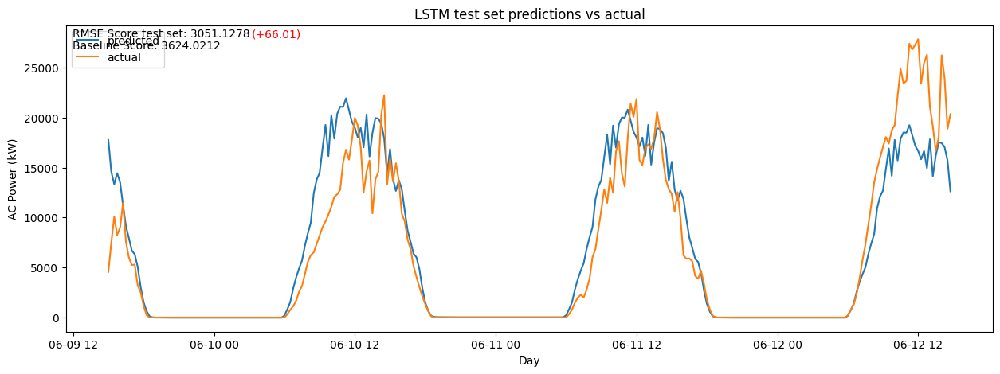

In [ ]:
### df_sep full data including all created features
inputs_sep_full_trains = []
labels_sep_full_trains = []
for i in range(4, len(cv_indices)-4):
    input_sep_full_train = (df_sep.iloc[cv_indices[i][0]] - df_sep.iloc[cv_indices[i][0]].mean()) \
                            / df_sep.iloc[cv_indices[i][0]].std()
    label_sep_full_train = (target.iloc[cv_indices[i][1]] - target.iloc[cv_indices[i][1]].mean()) \
                            / target.iloc[cv_indices[i][1]].std()
    label_sep_full_train = pd.DataFrame(label_sep_full_train, columns=['AC_POWER'])
    inputs_sep_full_trains.append(input_sep_full_train)
    labels_sep_full_trains.append(label_sep_full_train)

inputs_sep_full_train_stack = tf.stack(inputs_sep_full_trains)
labels_sep_full_train_stack = tf.stack(labels_sep_full_trains)

inputs_sep_full_vals = []
labels_sep_full_vals = []
for i in range(len(cv_indices)-4 , len(cv_indices)):
    input_sep_full_val = (df_sep.iloc[cv_indices[i][0]] - df_sep.iloc[cv_indices[i][0]].mean()) \
                            / df_sep.iloc[cv_indices[i][0]].std()
    label_sep_full_val = (target.iloc[cv_indices[i][1]] - target.iloc[cv_indices[i][1]].mean()) \
                            / target.iloc[cv_indices[i][1]].std()
    label_sep_full_val = pd.DataFrame(label_sep_full_val, columns=['AC_POWER'])
    inputs_sep_full_vals.append(input_sep_full_val)
    labels_sep_full_vals.append(label_sep_full_val)

inputs_sep_full_val_stack = tf.stack(inputs_sep_full_vals)
labels_sep_full_val_stack = tf.stack(labels_sep_full_vals)

val_full = (inputs_sep_full_val_stack, labels_sep_full_val_stack)

### Multi output all features
MAX_EPOCHS = 2000

all_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(16,
                         return_sequences=False),
    tf.keras.layers.Dense(96*1,
                          kernel_initializer=tf.initializers.zeros()),
    tf.keras.layers.Reshape([96, 1])
])

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=20,
                                                    mode='min',
                                                    restore_best_weights=True)

all_model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=[tf.keras.metrics.RootMeanSquaredError()])

history = all_model.fit(x=inputs_sep_full_train_stack, y=labels_sep_full_train_stack, epochs=MAX_EPOCHS,
                    validation_data=val_full,
                    callbacks=[early_stopping],
                    verbose=0);
day_1_labels = target.iloc[-day*3:-day*2]
day_2_labels = target.iloc[-day*2:-day*1]
day_3_labels = target.iloc[-day:]

test_labels = [day_1_labels, day_2_labels, day_3_labels]
test_labels_stack = tf.stack(test_labels)

day_1_inputs = (df_sep.iloc[-day*7:-day*3] - df_sep.iloc[-day*7:-day*3].mean()) \
                / df_sep.iloc[-day*7:-day*3].std()
day_2_inputs = (df_sep.iloc[-day*6:-day*2] - df_sep.iloc[-day*6:-day*2].mean()) \
                / df_sep.iloc[-day*6:-day*2].std()
day_3_inputs = (df_sep.iloc[-day*5:-day] - df_sep.iloc[-day*5:-day].mean()) \
                / df_sep.iloc[-day*5:-day].std()

test_inputs = [day_1_inputs, day_2_inputs, day_3_inputs]
test_inputs_stack = tf.stack(test_inputs)

target_norm_preds = all_model.predict(test_inputs_stack)

labels_preds_day_1 = target_norm_preds[0] * df_sep.iloc[-day*7:-day*3].AC_POWER.std() \
                    + df_sep.iloc[-day*7:-day*3].AC_POWER.mean()
labels_preds_day_2 = target_norm_preds[1] * df_sep.iloc[-day*6:-day*2].AC_POWER.std() \
                    + df_sep.iloc[-day*6:-day*2].AC_POWER.mean()
labels_preds_day_3 = target_norm_preds[2] * df_sep.iloc[-day*5:-day].AC_POWER.std() \
                    + df_sep.iloc[-day*5:-day].AC_POWER.mean()

day_1_error = mean_squared_error(test_labels_stack[0],
                                 labels_preds_day_1,
                                 squared=False)
day_2_error = mean_squared_error(test_labels_stack[1],
                                 labels_preds_day_2,
                                 squared=False)
day_3_error = mean_squared_error(test_labels_stack[2],
                                 labels_preds_day_3,
                                 squared=False)
lstm_rsme_score_test_set = np.round((day_1_error + day_2_error + day_3_error) / 3, 4)

labels_preds = np.concatenate([labels_preds_day_1,
                               labels_preds_day_2,
                               labels_preds_day_3],
                              axis = None)
test_labels = np.concatenate([test_labels_stack[0],
                              test_labels_stack[1],
                              test_labels_stack[2]],
                             axis = None)


fig, ax = plt.subplots(figsize=(15,5))
plt.plot(target.iloc[-3*day:].index, labels_preds)
plt.plot(target.iloc[-3*day:].index, test_labels)
plt.figtext(.13, .85, s=f'RMSE Score test set: {lstm_rsme_score_test_set}')

best_score = lstm_best['best_score']
lstm_score_difference = np.round(lstm_rsme_score_test_set - best_score, 2)
if (lstm_score_difference) < 0:
    plt.figtext(.28, .85, s=f'({lstm_score_difference}) New Best', color='green')
    lstm_best.update({'best_score': lstm_rsme_score_test_set})
elif (lstm_score_difference) == 0:
    plt.figtext(.28, .85, s=f'({lstm_score_difference})')
elif (lstm_score_difference) > 0:
    plt.figtext(.28, .85, s=f'(+{lstm_score_difference})', color='red')

plt.figtext(.13, .82, s=f'Baseline Score: {baseline_score}')
plt.title('LSTM test set predictions vs actual')
plt.legend(['predicted', 'actual'])
plt.ylabel('AC Power (kW)')
plt.xlabel('Day');


For all the extra features added (we now have 1789!!) there really isn't any difference. It is impressive though that the model is able to handle that many features in the first place. Since a greatly simplified model ended working best for our XGBoost model, let's try that again here. We can even use the same features we settled on for the XGBoost model.

1/1 [==============================] - 1s 696ms/step


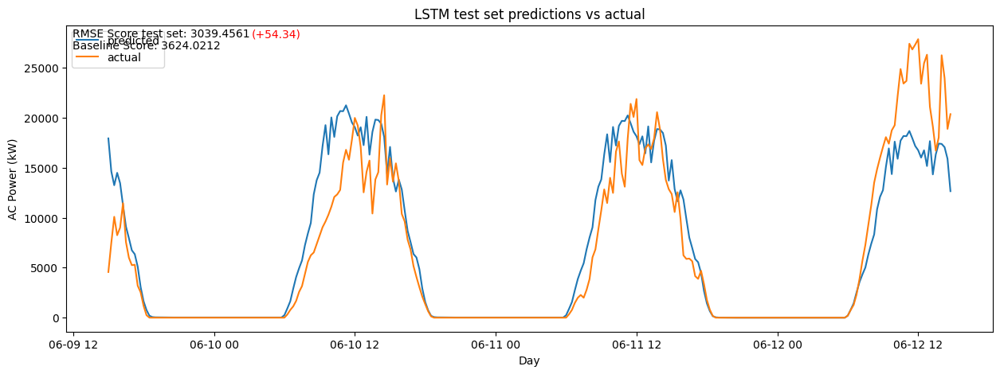

In [ ]:
df_sep = df_sep_dl

df_sep = day_cos_sin(df_sep, 1, type='cos')
df_sep['rolling_AC_POWER'] = df_sep.AC_POWER.rolling(4).mean()
df_sep['lag_dayTOTAL_YIELD192'] = df_sep.TOTAL_YIELD.shift(2*day)
df_sep_AC = df_sep[['AC_POWER']]
df_sep = df_sep[['Day_cos_1', 'rolling_AC_POWER', 'lag_dayTOTAL_YIELD192']]
imputer = KNNImputer(n_neighbors=10)
df_sep = pd.DataFrame(imputer.fit_transform(df_sep),
                      columns=df_sep.columns,
                      index=df_sep.index)
### df_sep full data including all created features
inputs_sep_simple_trains = []
labels_sep_simple_trains = []
for i in range(4, len(cv_indices)-4):
    input_sep_simple_train = (df_sep.iloc[cv_indices[i][0]] - df_sep.iloc[cv_indices[i][0]].mean()) \
                            / df_sep.iloc[cv_indices[i][0]].std()
    label_sep_simple_train = (target.iloc[cv_indices[i][1]] - target.iloc[cv_indices[i][1]].mean()) \
                            / target.iloc[cv_indices[i][1]].std()
    label_sep_simple_train = pd.DataFrame(label_sep_simple_train, columns=['AC_POWER'])
    inputs_sep_simple_trains.append(input_sep_simple_train)
    labels_sep_simple_trains.append(label_sep_simple_train)

inputs_sep_simple_train_stack = tf.stack(inputs_sep_simple_trains)
labels_sep_simple_train_stack = tf.stack(labels_sep_simple_trains)

inputs_sep_simple_vals = []
labels_sep_simple_vals = []
for i in range(len(cv_indices)-4 , len(cv_indices)):
    input_sep_simple_val = (df_sep.iloc[cv_indices[i][0]] - df_sep.iloc[cv_indices[i][0]].mean()) \
                            / df_sep.iloc[cv_indices[i][0]].std()
    label_sep_simple_val = (target.iloc[cv_indices[i][1]] - target.iloc[cv_indices[i][1]].mean()) \
                            / target.iloc[cv_indices[i][1]].std()
    label_sep_simple_val = pd.DataFrame(label_sep_simple_val, columns=['AC_POWER'])
    inputs_sep_simple_vals.append(input_sep_simple_val)
    labels_sep_simple_vals.append(label_sep_simple_val)

inputs_sep_simple_val_stack = tf.stack(inputs_sep_simple_vals)
labels_sep_simple_val_stack = tf.stack(labels_sep_simple_vals)

val_simple = (inputs_sep_simple_val_stack, labels_sep_simple_val_stack)
### Multi output simple model. Only with AC_POWER and a datetime index.
MAX_EPOCHS = 2000

previous_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(16,
                         return_sequences=False),
    tf.keras.layers.Dense(96*1,
                          kernel_initializer=tf.initializers.zeros()),
    tf.keras.layers.Reshape([96, 1])
])

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=20,
                                                    mode='min',
                                                    restore_best_weights=True)

previous_model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=[tf.keras.metrics.RootMeanSquaredError()])

history = previous_model.fit(x=inputs_sep_simple_train_stack, y=labels_sep_simple_train_stack, epochs=MAX_EPOCHS,
                    validation_data=val_simple,
                    callbacks=[early_stopping],
                    verbose=0);
day_1_labels = target.iloc[-day*3:-day*2]
day_2_labels = target.iloc[-day*2:-day*1]
day_3_labels = target.iloc[-day:]

test_labels = [day_1_labels, day_2_labels, day_3_labels]
test_labels_stack = tf.stack(test_labels)

day_1_inputs = (df_sep.iloc[-day*7:-day*3] - df_sep.iloc[-day*7:-day*3].mean()) \
                / df_sep.iloc[-day*7:-day*3].std()
day_2_inputs = (df_sep.iloc[-day*6:-day*2] - df_sep.iloc[-day*6:-day*2].mean()) \
                / df_sep.iloc[-day*6:-day*2].std()
day_3_inputs = (df_sep.iloc[-day*5:-day] - df_sep.iloc[-day*5:-day].mean()) \
                / df_sep.iloc[-day*5:-day].std()

test_inputs = [day_1_inputs, day_2_inputs, day_3_inputs]
test_inputs_stack = tf.stack(test_inputs)

target_norm_preds = previous_model.predict(test_inputs_stack)

labels_preds_day_1 = target_norm_preds[0] * df_sep_AC.iloc[-day*7:-day*3].AC_POWER.std() \
                    + df_sep_AC.iloc[-day*7:-day*3].AC_POWER.mean()
labels_preds_day_2 = target_norm_preds[1] * df_sep_AC.iloc[-day*6:-day*2].AC_POWER.std() \
                    + df_sep_AC.iloc[-day*6:-day*2].AC_POWER.mean()
labels_preds_day_3 = target_norm_preds[2] * df_sep_AC.iloc[-day*5:-day].AC_POWER.std() \
                    + df_sep_AC.iloc[-day*5:-day].AC_POWER.mean()

day_1_error = mean_squared_error(test_labels_stack[0],
                                 labels_preds_day_1,
                                 squared=False)
day_2_error = mean_squared_error(test_labels_stack[1],
                                 labels_preds_day_2,
                                 squared=False)
day_3_error = mean_squared_error(test_labels_stack[2],
                                 labels_preds_day_3,
                                 squared=False)
lstm_rsme_score_test_set = np.round((day_1_error + day_2_error + day_3_error) / 3, 4)

labels_preds = np.concatenate([labels_preds_day_1,
                               labels_preds_day_2,
                               labels_preds_day_3],
                              axis = None)
test_labels = np.concatenate([test_labels_stack[0],
                              test_labels_stack[1],
                              test_labels_stack[2]],
                             axis = None)



fig, ax = plt.subplots(figsize=(15,5))
plt.plot(target.iloc[-3*day:].index, labels_preds)
plt.plot(target.iloc[-3*day:].index, test_labels)
plt.figtext(.13, .85, s=f'RMSE Score test set: {lstm_rsme_score_test_set}')
best_score = lstm_best['best_score']
lstm_score_difference = np.round(lstm_rsme_score_test_set - best_score, 2)
if (lstm_score_difference) < 0:
    plt.figtext(.28, .85, s=f'({lstm_score_difference}) New Best', color='green')
    lstm_best.update({'best_score': lstm_rsme_score_test_set})
elif (lstm_score_difference) == 0:
    plt.figtext(.28, .85, s=f'({lstm_score_difference})')
elif (lstm_score_difference) > 0:
    plt.figtext(.28, .85, s=f'(+{lstm_score_difference})', color='red')
plt.figtext(.13, .82, s=f'Baseline Score: {baseline_score}')
plt.title('LSTM test set predictions vs actual')
plt.legend(['predicted', 'actual'])
plt.ylabel('AC Power (kW)')
plt.xlabel('Day');

1/1 [==============================] - 1s 568ms/step


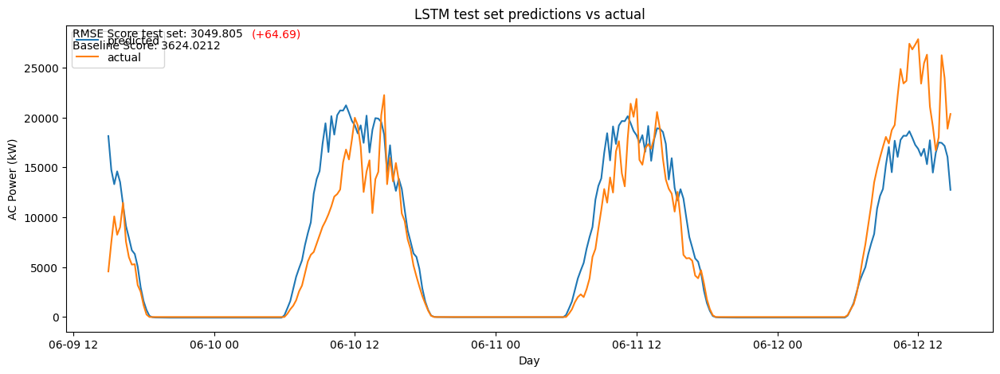

In [ ]:
df_sep = df_sep_dl

df_sep = day_cos_sin(df_sep, 1, type='cos')
#Since the features don't include AC_POWER any more
#have set aside df of just it for (un)normalizing the predictions.
df_sep_AC = df_sep[['AC_POWER']]
df_sep = df_sep[['Day_cos_1']]
### df_sep full data including all created features
inputs_sep_simple_trains = []
labels_sep_simple_trains = []
for i in range(4, len(cv_indices)-4):
    input_sep_simple_train = (df_sep.iloc[cv_indices[i][0]] - df_sep.iloc[cv_indices[i][0]].mean()) \
                            / df_sep.iloc[cv_indices[i][0]].std()
    label_sep_simple_train = (target.iloc[cv_indices[i][1]] - target.iloc[cv_indices[i][1]].mean()) \
                            / target.iloc[cv_indices[i][1]].std()
    label_sep_simple_train = pd.DataFrame(label_sep_simple_train, columns=['AC_POWER'])
    inputs_sep_simple_trains.append(input_sep_simple_train)
    labels_sep_simple_trains.append(label_sep_simple_train)

inputs_sep_simple_train_stack = tf.stack(inputs_sep_simple_trains)
labels_sep_simple_train_stack = tf.stack(labels_sep_simple_trains)

inputs_sep_simple_vals = []
labels_sep_simple_vals = []
for i in range(len(cv_indices)-4 , len(cv_indices)):
    input_sep_simple_val = (df_sep.iloc[cv_indices[i][0]] - df_sep.iloc[cv_indices[i][0]].mean()) \
                            / df_sep.iloc[cv_indices[i][0]].std()
    label_sep_simple_val = (target.iloc[cv_indices[i][1]] - target.iloc[cv_indices[i][1]].mean()) \
                            / target.iloc[cv_indices[i][1]].std()
    label_sep_simple_val = pd.DataFrame(label_sep_simple_val, columns=['AC_POWER'])
    inputs_sep_simple_vals.append(input_sep_simple_val)
    labels_sep_simple_vals.append(label_sep_simple_val)

inputs_sep_simple_val_stack = tf.stack(inputs_sep_simple_vals)
labels_sep_simple_val_stack = tf.stack(labels_sep_simple_vals)

val_simple = (inputs_sep_simple_val_stack, labels_sep_simple_val_stack)
### Multi output basic model. Only with Day_cos and a datetime index.
MAX_EPOCHS = 2000

basic_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(16,
                         return_sequences=False),
    tf.keras.layers.Dense(96*1,
                          kernel_initializer=tf.initializers.zeros()),
    tf.keras.layers.Reshape([96, 1])
])

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=20,
                                                    mode='min',
                                                    restore_best_weights=True)

basic_model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=[tf.keras.metrics.RootMeanSquaredError()])

history = basic_model.fit(x=inputs_sep_simple_train_stack, y=labels_sep_simple_train_stack, epochs=MAX_EPOCHS,
                    validation_data=val_simple,
                    callbacks=[early_stopping],
                    verbose=0);
day_1_labels = target.iloc[-day*3:-day*2]
day_2_labels = target.iloc[-day*2:-day*1]
day_3_labels = target.iloc[-day:]

test_labels = [day_1_labels, day_2_labels, day_3_labels]
test_labels_stack = tf.stack(test_labels)

day_1_inputs = (df_sep.iloc[-day*7:-day*3] - df_sep.iloc[-day*7:-day*3].mean()) \
                / df_sep.iloc[-day*7:-day*3].std()
day_2_inputs = (df_sep.iloc[-day*6:-day*2] - df_sep.iloc[-day*6:-day*2].mean()) \
                / df_sep.iloc[-day*6:-day*2].std()
day_3_inputs = (df_sep.iloc[-day*5:-day] - df_sep.iloc[-day*5:-day].mean()) \
                / df_sep.iloc[-day*5:-day].std()

test_inputs = [day_1_inputs, day_2_inputs, day_3_inputs]
test_inputs_stack = tf.stack(test_inputs)

target_norm_preds = basic_model.predict(test_inputs_stack)

labels_preds_day_1 = target_norm_preds[0] * df_sep_AC.iloc[-day*7:-day*3].AC_POWER.std() \
                    + df_sep_AC.iloc[-day*7:-day*3].AC_POWER.mean()
labels_preds_day_2 = target_norm_preds[1] * df_sep_AC.iloc[-day*6:-day*2].AC_POWER.std() \
                    + df_sep_AC.iloc[-day*6:-day*2].AC_POWER.mean()
labels_preds_day_3 = target_norm_preds[2] * df_sep_AC.iloc[-day*5:-day].AC_POWER.std() \
                    + df_sep_AC.iloc[-day*5:-day].AC_POWER.mean()

day_1_error = mean_squared_error(test_labels_stack[0],
                                 labels_preds_day_1,
                                 squared=False)
day_2_error = mean_squared_error(test_labels_stack[1],
                                 labels_preds_day_2,
                                 squared=False)
day_3_error = mean_squared_error(test_labels_stack[2],
                                 labels_preds_day_3,
                                 squared=False)
lstm_rsme_score_test_set = np.round((day_1_error + day_2_error + day_3_error) / 3, 4)

labels_preds = np.concatenate([labels_preds_day_1,
                               labels_preds_day_2,
                               labels_preds_day_3],
                              axis = None)
test_labels = np.concatenate([test_labels_stack[0],
                              test_labels_stack[1],
                              test_labels_stack[2]],
                             axis = None)



fig, ax = plt.subplots(figsize=(15,5))
plt.plot(target.iloc[-3*day:].index, labels_preds)
plt.plot(target.iloc[-3*day:].index, test_labels)
plt.figtext(.13, .85, s=f'RMSE Score test set: {lstm_rsme_score_test_set}')
best_score = lstm_best['best_score']
lstm_score_difference = np.round(lstm_rsme_score_test_set - best_score, 2)
if (lstm_score_difference) < 0:
    plt.figtext(.28, .85, s=f'({lstm_score_difference}) New Best', color='green')
    lstm_best.update({'best_score': lstm_rsme_score_test_set})
elif (lstm_score_difference) == 0:
    plt.figtext(.28, .85, s=f'({lstm_score_difference})')
elif (lstm_score_difference) > 0:
    plt.figtext(.28, .85, s=f'(+{lstm_score_difference})', color='red')
plt.figtext(.13, .82, s=f'Baseline Score: {baseline_score}')
plt.title('LSTM test set predictions vs actual')
plt.legend(['predicted', 'actual'])
plt.ylabel('AC Power (kW)')
plt.xlabel('Day');

About the same performance, but even simpler! Experimenting some with different combinations of features and some basic parameter tuning, I was not able to come up with better results. So, let's go with the simple model that just has the daily cosine feature. Since our deep learning model initially preferred data with the inverters separated vs the much simpler aggregated data, it is a bit surprising that the simplest model did best. Just like we found with our XGBoost model, however, it seems like since there is enough regularity in the daily cycle of AC Power generation the model doesn't require much complexity to capture the broad strokes of the target. Overall, the RNN/LSTM model outperformed the XGBoost model on the 3-day test period by ~2% (with a score of ~2870 kW). This isn't a huge difference of course and is only over our 3-day test period, but it is enough for us to pick our RNN/LSTM model as the winner.

Wait, wasn't there another plant?
Yes, let's not forget there is a whole other solar plant and associated weather data to model. We'll take our most successful model so far and make a full pipeline out of it to process the 2nd solar plant data and make a day ahead forecast for it.

Pipeline
To make a pipeline we'll break out the process into multiple functions based on different parts of the modeling process. Along the way we'll add in some additional parameters to increase the flexibility of our model. Specifically, let's build-in the option to change the forecast length to up to a week ahead.

1/1 [==============================] - 0s 368ms/step


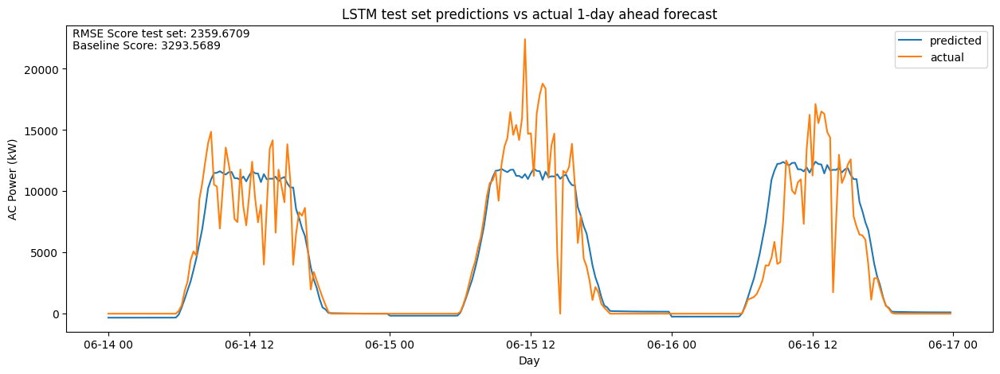

In [ ]:
def data_preprocessing(df_gen_csv, df_weather_csv, imputer=KNNImputer(n_neighbors=10),
                       gen_datetime_format='%Y-%m-%d %H:%M:%S' , weather_datetime_format='%Y-%m-%d %H:%M:%S'):
    """This takes in the raw plant generation and weather data and
    performs the basic preprocessing, joining the datasets,
    adding rows for missing datetimes, and imputing missing data"""

    df_gen = pd.read_csv(df_gen_csv)
    df_gen = df_gen.drop('PLANT_ID', axis=1)

    df_gen['INVERTER'] = df_gen.SOURCE_KEY.map({df_gen.SOURCE_KEY.unique()[i-1]: \
                                                f'INVERTER_{i}' \
                                                for i in range(1, len(df_gen.SOURCE_KEY.unique()) +1)})
    df_gen = df_gen.drop('SOURCE_KEY', axis=1)

    inverters = df_gen.INVERTER.unique()

    df_gen['DATE_TIME'] = pd.to_datetime(df_gen.DATE_TIME, format=gen_datetime_format)

    df_weather = pd.read_csv(df_weather_csv)

    df_weather = df_weather.drop(['PLANT_ID', 'SOURCE_KEY'], axis=1)
    df_weather['DATE_TIME'] = pd.to_datetime(df_weather.DATE_TIME, format=weather_datetime_format)

    datetimes_full = pd.Series(pd.date_range(df_gen.DATE_TIME.min(),
                                             df_gen.DATE_TIME.max(),
                                             freq='15min'),
                               name='DATE_TIME')

    dfs_gen = []
    for i in inverters:
        df_inverter = df_gen[df_gen.INVERTER == i]
        df_inverter = df_inverter.merge(datetimes_full, on='DATE_TIME', how='right')
        df_inverter['INVERTER'] = i
        dfs_gen.append(df_inverter)
    df_gen = pd.concat(dfs_gen)

    df = df_gen.merge(df_weather, on='DATE_TIME', how='left')

    df['HOUR'] = df.DATE_TIME.dt.hour
    df['DAY'] = df.DATE_TIME.dt.dayofyear
    df['DAY_WEEK'] = df.DATE_TIME.dt.dayofweek
    df['MINUTES_15'] = df.DATE_TIME.dt.time

    #This maps the 15 minute intervals over the course of the day to ints 1-96.
    df['MINUTES_15'] = df.MINUTES_15.map({df.MINUTES_15.unique()[i-1]:i for i in range(1, 97)})
    #Change day of year to day of data
    df['DAY'] = df.DAY.map({df.DAY.unique()[i-1]:i for i in range(1, 35)})

    #Had a go through a few tries to settle on MINUTES_15 = 75 as a good starting point for night.
    nighttime = [i for i in range(75,97)]
    #Making these changes to the original df
    df['DAILY_YIELD'] = df['DAILY_YIELD'].mask(df.HOUR.isin([0]), 0)
    #We need a maximum daily yield for each inverter separately
    daily_yield = df.copy()
    daily_yield = df.merge(pd.DataFrame({'DAILY_YIELD_DAY_MAX' : \
                                         df.groupby([ 'INVERTER', 'DAY'])\
                                         .max()['DAILY_YIELD']})\
                           .reset_index(),
                           on=['INVERTER', 'DAY'],
                           how='right')
    df['DAILY_YIELD'] = df['DAILY_YIELD'].mask(df.MINUTES_15.isin(nighttime),
                                               daily_yield['DAILY_YIELD_DAY_MAX'])

    imputer = KNNImputer(n_neighbors=10)
    inverter_dfs = []
    inverter_df = None
    for i in inverters:
        inverter_df = df[df.INVERTER == i]
        inverter_df.pop('INVERTER')
        inverter_df.index = inverter_df['DATE_TIME']
        datetime = inverter_df.pop('DATE_TIME')
        inverter_df = pd.DataFrame(imputer.fit_transform(inverter_df),
                                   columns=inverter_df.columns,
                                   index=datetime)
        inverter_df['INVERTER'] = i
        inverter_df = inverter_df.reset_index()
        inverter_dfs.append(inverter_df)
    df = pd.concat(inverter_dfs)
    return df

def basic_features(df, inverters_split = True, weather_included = True):
    """This makes the basic datetime features out of the preprocessed df and
    also creates 4 different dfs for inverters being split or not and
    whether or not the weather data is included"""
    generation = ['AC_POWER', 'DC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']
    weather = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
    all_features = ['AC_POWER', 'DC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD',
                    'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
    #Aggregating data across inverters. We will sum the generation data and take the mean of the weather data.
    #Also, adding back basic datetime features
    df_agg = pd.concat([df.groupby('DATE_TIME')[generation].sum(numeric_only=True),
                        df.groupby('DATE_TIME').mean(numeric_only=True)[weather]],
                       axis=1)

    df_agg['HOUR'] = df_agg.index.hour
    df_agg['DAY'] = df_agg.index.dayofyear
    df_agg['DAY_WEEK'] = df_agg.index.dayofweek
    df_agg['MINUTES_15'] = df_agg.index.time

    #This maps the 15 minute intervals over the course of the day to ints 1-96.
    df_agg['MINUTES_15'] = df_agg.MINUTES_15.map({df_agg.MINUTES_15.unique()[i-1]:i for i in range(1, 97)})
    #Change day of year to day of data
    df_agg['DAY'] = df_agg.DAY.map({df_agg.DAY.unique()[i-1]:i for i in range(1, 35)})
    #Pivoting inverter generation data as features and adding back datetime features
    inverter_dfs = []
    for i in inverters:
        df_inverter = df[df.INVERTER == i][['INVERTER', 'DATE_TIME', 'AC_POWER',
                                            'DC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']]
        df_inverter.pop('INVERTER')
        date_time = df_inverter.pop('DATE_TIME')
        df_inverter.index = date_time
        df_inverter.columns += f'_{i}'
        inverter_dfs.append(df_inverter)

    df_sep = pd.concat(inverter_dfs, axis=1, ignore_index=False)
    df_sep = pd.concat([df_sep, df_agg], axis=1)

    all_features_seperated = list(df_sep.columns)

    #Without the weather data
    df_agg_no_weather = df_agg.drop(weather, axis=1)
    df_sep_no_weather = df_sep.drop(weather, axis=1)

    if inverters_split == True & weather_included == True:
        return df_sep
    elif inverters_split == True & weather_included == False:
        return df_sep_no_weather
    elif inverters_split == False & weather_included == True:
        return df_agg
    else:
        return df_agg_no_weather

def target_cv_baseline(df, forecast_length_days = 1, test_size=96, train_size=4*96):
    """This makes the cv indices for the model and determines the forecast length"""
    if forecast_length_days > 7:
        return print('Error forecast over 7 days ahead. Model not intended for long-term forecasts.')
    day = 96
    forecast_length = forecast_length_days * day
    #shifting to day ahead and dropping nulls cause by the shift
    target = df.groupby('DATE_TIME').sum(numeric_only=True).AC_POWER.shift(-forecast_length)
    target = target.dropna()

    #last 3 days for testing and the rest for training
    target_test = target[-3*day:]
    target_train = target[:-3*day]
    #moving target back forecast length
    baseline_preds = target.shift(forecast_length)[-3*day:]
    baseline_score = np.round(mean_squared_error(target_test, baseline_preds, squared=False), 4)

    n_splits = len(df.iloc[:-day*(3 + forecast_length_days)]) // (day) - 1
    tscv = TimeSeriesSplit(test_size=test_size, n_splits=n_splits, max_train_size=train_size)
    cv_indices = []
    for train_indices, test_indices in tscv.split(df.iloc[:-day*(3 + forecast_length_days)]):
        cv_indices.append((train_indices, test_indices))

    return target, cv_indices, baseline_score, forecast_length_days


def day_cos_sin(df, freq=1, type='cos'):
    timestamp_s = df.index.map(pd.Timestamp.timestamp)
    day_s = 24*60*60
    if type=='both':
        df[f'Day_sin_{freq}'] = np.sin(timestamp_s  * (2 * freq * np.pi / day_s))
        df[f'Day_cos_{freq}'] = np.cos(timestamp_s * (2 * freq * np.pi / day_s))
    elif type=='cos':
        df[f'Day_cos_{freq}'] = np.cos(timestamp_s * (2 * freq * np.pi / day_s))
    elif type=='sin':
        df[f'Day_sin_{freq}'] = np.sin(timestamp_s  * (2 * freq * np.pi / day_s))
    return df

def inputs_labels_creation(df, target, cv_indices, feature_list=['Day_cos_1']):
    """This makes the inputs and labels for our deep learning model.
    It also allows us to select the features we want"""
    features = df[feature_list]
    inputs_trains = []
    labels_trains = []
    for i in range(4, len(cv_indices)-4):
        input_train = ( features.iloc[cv_indices[i][0]] -  features.iloc[cv_indices[i][0]].mean()) \
                        /  features.iloc[cv_indices[i][0]].std()
        label_train = (target.iloc[cv_indices[i][1]] - target.iloc[cv_indices[i][1]].mean()) \
                        / target.iloc[cv_indices[i][1]].std()
        label_train = pd.DataFrame(label_train, columns=['AC_POWER'])
        inputs_trains.append(input_train)
        labels_trains.append(label_train)

    inputs_train_stack = tf.stack(inputs_trains)
    labels_train_stack = tf.stack(labels_trains)

    inputs_vals = []
    labels_vals = []
    for i in range(len(cv_indices)-4 , len(cv_indices)):
        input_val = ( features.iloc[cv_indices[i][0]] -  features.iloc[cv_indices[i][0]].mean()) \
                    /  features.iloc[cv_indices[i][0]].std()
        label_val = (target.iloc[cv_indices[i][1]] - target.iloc[cv_indices[i][1]].mean()) \
                    / target.iloc[cv_indices[i][1]].std()
        label_val = pd.DataFrame(label_val, columns=['AC_POWER'])
        inputs_vals.append(input_val)
        labels_vals.append(label_val)

    inputs_val_stack = tf.stack(inputs_vals)
    labels_val_stack = tf.stack(labels_vals)

    val_stack = (inputs_val_stack, labels_val_stack)

    return inputs_train_stack, labels_train_stack, val_stack, features


def model_train(df, target, features, inputs_train_stack,
                labels_train_stack, val_stack,
                baseline_score, forecast_length_days, lstm_units = 16, verbose=2):
    """This trains our deep learning model and outputs the predictions and results"""
    MAX_EPOCHS = 2000

    model = tf.keras.Sequential([

        tf.keras.layers.LSTM(lstm_units, return_sequences=False),
        tf.keras.layers.Dense(96*1,
                              kernel_initializer=tf.initializers.zeros()),
        tf.keras.layers.Reshape([96, 1])
    ])

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                        patience=20,
                                                        mode='min',
                                                        restore_best_weights=True)

    model.compile(loss=tf.keras.losses.MeanSquaredError(),
                    optimizer=tf.keras.optimizers.Adam(),
                    metrics=[tf.keras.metrics.RootMeanSquaredError()])

    history = model.fit(x=inputs_train_stack, y=labels_train_stack, epochs=MAX_EPOCHS,
                        validation_data=val_stack,
                        callbacks=[early_stopping],
                        verbose=verbose);

    day_1_labels = target.iloc[-day*3:-day*2]
    day_2_labels = target.iloc[-day*2:-day*1]
    day_3_labels = target.iloc[-day:]

    test_labels = [day_1_labels, day_2_labels, day_3_labels]
    test_labels_stack = tf.stack(test_labels)

    day_1_inputs = (features.iloc[-day*7:-day*3] - features.iloc[-day*7:-day*3].mean()) \
                    / features.iloc[-day*7:-day*3].std()
    day_2_inputs = (features.iloc[-day*6:-day*2] - features.iloc[-day*6:-day*2].mean()) \
                    / features.iloc[-day*6:-day*2].std()
    day_3_inputs = (features.iloc[-day*5:-day] - features.iloc[-day*5:-day].mean()) \
                    / features.iloc[-day*5:-day].std()

    test_inputs = [day_1_inputs, day_2_inputs, day_3_inputs]
    test_inputs_stack = tf.stack(test_inputs)

    target_norm_preds = model.predict(test_inputs_stack)

    labels_preds_day_1 = target_norm_preds[0] * df.iloc[-day*7:-day*3].AC_POWER.std() \
                        + df.iloc[-day*7:-day*3].AC_POWER.mean()
    labels_preds_day_2 = target_norm_preds[1] * df.iloc[-day*6:-day*2].AC_POWER.std() \
                        + df.iloc[-day*6:-day*2].AC_POWER.mean()
    labels_preds_day_3 = target_norm_preds[2] * df.iloc[-day*5:-day].AC_POWER.std() \
                        + df.iloc[-day*5:-day].AC_POWER.mean()


    day_1_error = mean_squared_error(test_labels_stack[0],
                                     labels_preds_day_1,
                                     squared=False)
    day_2_error = mean_squared_error(test_labels_stack[1],
                                     labels_preds_day_2,
                                     squared=False)
    day_3_error = mean_squared_error(test_labels_stack[2],
                                     labels_preds_day_3,
                                     squared=False)
    lstm_rsme_score_test_set = np.round((day_1_error + day_2_error + day_3_error) / 3, 4)

    labels_preds = np.concatenate([labels_preds_day_1,
                                   labels_preds_day_2,
                                   labels_preds_day_3],
                                  axis = None)
    test_labels = np.concatenate([test_labels_stack[0],
                                  test_labels_stack[1],
                                  test_labels_stack[2]],
                                 axis = None)

    fig, ax = plt.subplots(figsize=(15,5))
    plt.plot(target.iloc[-3*day:].index, labels_preds)
    plt.plot(target.iloc[-3*day:].index, test_labels)
    plt.figtext(.13, .85, s=f'RMSE Score test set: {lstm_rsme_score_test_set}')

    try:
        best_score = lstm_best['best_score']
        lstm_score_difference = np.round(lstm_rsme_score_test_set - best_score, 2)
        if (lstm_score_difference) < 0:
            plt.figtext(.28, .85, s=f'({lstm_score_difference}) New Best', color='green')
            lstm_best.update({'best_score': lstm_rsme_score_test_set})
        elif (lstm_score_difference) == 0:
            plt.figtext(.28, .85, s=f'({lstm_score_difference})')
        elif (lstm_score_difference) > 0:
            plt.figtext(.28, .85, s=f'(+{lstm_score_difference})', color='red')
    except:
        lstm_best = {'best_score': lstm_rsme_score_test_set}

    plt.figtext(.13, .82, s=f'Baseline Score: {baseline_score}')
    plt.title(f'LSTM test set predictions vs actual {forecast_length_days}-day ahead forecast')
    plt.legend(['predicted', 'actual'])
    plt.ylabel('AC Power (kW)')
    plt.xlabel('Day')

    score_results = {'baseline_score' : baseline_score, 'model_score' : lstm_rsme_score_test_set}
    predictions = pd.Series(labels_preds,
                            index=target.iloc[-3*day:].index,
                            name='AC Power Generation Predictions')


    return predictions, score_results, fig
#Now we can apply our functions to Plant 2.

df = data_preprocessing('Solar_Power_Plant_2_Generation_Data_Maharashta.csv',
                        'Solar_Power_Plant_2_Weather_Sensor_Data_Maharashta.csv',
                        imputer=KNNImputer(n_neighbors=10))
df = basic_features(df)
df = day_cos_sin(df, freq=1, type='cos')
target, cv_indices, baseline_score, forecast_length_days = target_cv_baseline(df, forecast_length_days = 1)
inputs_train_stack, labels_train_stack, val_stack, features = inputs_labels_creation(df, target=target,
                                                                                     cv_indices=cv_indices,
                                                                                     feature_list=['Day_cos_1'])
predictions, score_results, fig =  model_train(df, target=target,
                                               inputs_train_stack=inputs_train_stack,
                                               labels_train_stack=labels_train_stack,
                                               val_stack=val_stack,
                                               lstm_units=16, verbose=0,
                                               forecast_length_days=forecast_length_days,
                                               baseline_score = baseline_score,
                                               features=features)

Our pipeline works. You can tell how different the second plant is based on the daily shape our model picked out for power generation. Here are the predictions generated from our model for the last 3 days of our data.

In [ ]:
predictions

DATE_TIME
2020-06-14 00:00:00   -325.933105
2020-06-14 00:15:00   -325.933105
2020-06-14 00:30:00   -325.933105
2020-06-14 00:45:00   -325.933105
2020-06-14 01:00:00   -325.933105
                          ...    
2020-06-16 22:45:00    112.914551
2020-06-16 23:00:00    106.829102
2020-06-16 23:15:00    107.248535
2020-06-16 23:30:00    108.686523
2020-06-16 23:45:00    108.686523
Name: AC Power Generation Predictions, Length: 288, dtype: float32

Our model does struggle just a bit getting all the nighttime intervals to 0. Our daily cosine feature might be confusing it some. We can just add manually correct those in our model_train function to help it out using the following:

In [ ]:
"""
labels_preds_day_1[(labels_preds_day_1 < 350)] = 0
labels_preds_day_2[(labels_preds_day_2 < 350)] = 0
labels_preds_day_3[(labels_preds_day_3 < 350)] = 0
""";

Let's update the model_train function and run it again.

1/1 [==============================] - 0s 340ms/step


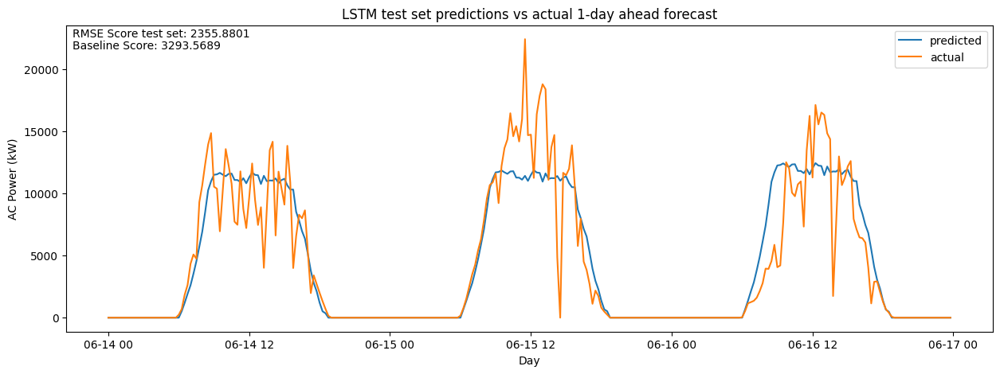

In [ ]:
def model_train(df, target, features, inputs_train_stack,
                labels_train_stack, val_stack, baseline_score, forecast_length_days, lstm_units = 16, verbose=2):
    """This trains our deep learning model and outputs the predictions and results"""
    MAX_EPOCHS = 2000

    model = tf.keras.Sequential([

        tf.keras.layers.LSTM(lstm_units, return_sequences=False),
        tf.keras.layers.Dense(96*1,
                              kernel_initializer=tf.initializers.zeros()),
        tf.keras.layers.Reshape([96, 1])
    ])

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                        patience=20,
                                                        mode='min',
                                                        restore_best_weights=True)

    model.compile(loss=tf.keras.losses.MeanSquaredError(),
                    optimizer=tf.keras.optimizers.Adam(),
                    metrics=[tf.keras.metrics.RootMeanSquaredError()])

    history = model.fit(x=inputs_train_stack, y=labels_train_stack, epochs=MAX_EPOCHS,
                        validation_data=val_stack,
                        callbacks=[early_stopping],
                        verbose=verbose);

    day_1_labels = target.iloc[-day*3:-day*2]
    day_2_labels = target.iloc[-day*2:-day*1]
    day_3_labels = target.iloc[-day:]

    test_labels = [day_1_labels, day_2_labels, day_3_labels]
    test_labels_stack = tf.stack(test_labels)

    day_1_inputs = (features.iloc[-day*7:-day*3] - features.iloc[-day*7:-day*3].mean()) \
                    / features.iloc[-day*7:-day*3].std()
    day_2_inputs = (features.iloc[-day*6:-day*2] - features.iloc[-day*6:-day*2].mean()) \
                    / features.iloc[-day*6:-day*2].std()
    day_3_inputs = (features.iloc[-day*5:-day] - features.iloc[-day*5:-day].mean()) \
                    / features.iloc[-day*5:-day].std()

    test_inputs = [day_1_inputs, day_2_inputs, day_3_inputs]
    test_inputs_stack = tf.stack(test_inputs)

    target_norm_preds = model.predict(test_inputs_stack)

    labels_preds_day_1 = target_norm_preds[0] * df.iloc[-day*7:-day*3].AC_POWER.std() \
                        + df.iloc[-day*7:-day*3].AC_POWER.mean()
    labels_preds_day_2 = target_norm_preds[1] * df.iloc[-day*6:-day*2].AC_POWER.std() \
                        + df.iloc[-day*6:-day*2].AC_POWER.mean()
    labels_preds_day_3 = target_norm_preds[2] * df.iloc[-day*5:-day].AC_POWER.std() \
                        + df.iloc[-day*5:-day].AC_POWER.mean()

    #Update to fix nighttime/morning values
    labels_preds_day_1[(labels_preds_day_1 < 350)] = 0
    labels_preds_day_2[(labels_preds_day_2 < 350)] = 0
    labels_preds_day_3[(labels_preds_day_3 < 350)] = 0

    day_1_error = mean_squared_error(test_labels_stack[0],
                                     labels_preds_day_1,
                                     squared=False)
    day_2_error = mean_squared_error(test_labels_stack[1],
                                     labels_preds_day_2,
                                     squared=False)
    day_3_error = mean_squared_error(test_labels_stack[2],
                                     labels_preds_day_3,
                                     squared=False)
    lstm_rsme_score_test_set = np.round((day_1_error + day_2_error + day_3_error) / 3, 4)

    labels_preds = np.concatenate([labels_preds_day_1,
                                   labels_preds_day_2,
                                   labels_preds_day_3],
                                  axis = None)
    test_labels = np.concatenate([test_labels_stack[0],
                                  test_labels_stack[1],
                                  test_labels_stack[2]],
                                 axis = None)

    fig, ax = plt.subplots(figsize=(15,5))
    plt.plot(target.iloc[-3*day:].index, labels_preds)
    plt.plot(target.iloc[-3*day:].index, test_labels)
    plt.figtext(.13, .85, s=f'RMSE Score test set: {lstm_rsme_score_test_set}')

    try:
        best_score = lstm_best['best_score']
        lstm_score_difference = np.round(lstm_rsme_score_test_set - best_score, 2)
        if (lstm_score_difference) < 0:
            plt.figtext(.28, .85, s=f'({lstm_score_difference}) New Best', color='green')
            lstm_best.update({'best_score': lstm_rsme_score_test_set})
        elif (lstm_score_difference) == 0:
            plt.figtext(.28, .85, s=f'({lstm_score_difference})')
        elif (lstm_score_difference) > 0:
            plt.figtext(.28, .85, s=f'(+{lstm_score_difference})', color='red')
    except:
        lstm_best = {'best_score': lstm_rsme_score_test_set}

    plt.figtext(.13, .82, s=f'Baseline Score: {baseline_score}')
    plt.title(f'LSTM test set predictions vs actual {forecast_length_days}-day ahead forecast')
    plt.legend(['predicted', 'actual'])
    plt.ylabel('AC Power (kW)')
    plt.xlabel('Day')

    score_results = {'baseline_score' : baseline_score, 'model_score' : lstm_rsme_score_test_set}
    predictions = pd.Series(labels_preds,
                            index=target.iloc[-3*day:].index,
                            name='AC Power Generation Predictions')


    return predictions, score_results, fig
predictions, score_results, fig =  model_train(df, target=target,
                                               inputs_train_stack=inputs_train_stack,
                                               labels_train_stack=labels_train_stack,
                                               val_stack=val_stack,
                                               lstm_units=16, verbose=0,
                                               forecast_length_days=forecast_length_days,
                                               baseline_score = baseline_score,
                                               features=features)

# **That does help to clean it up some. Let's also try a 2-day ahead forecast.**

1/1 [==============================] - 0s 467ms/step


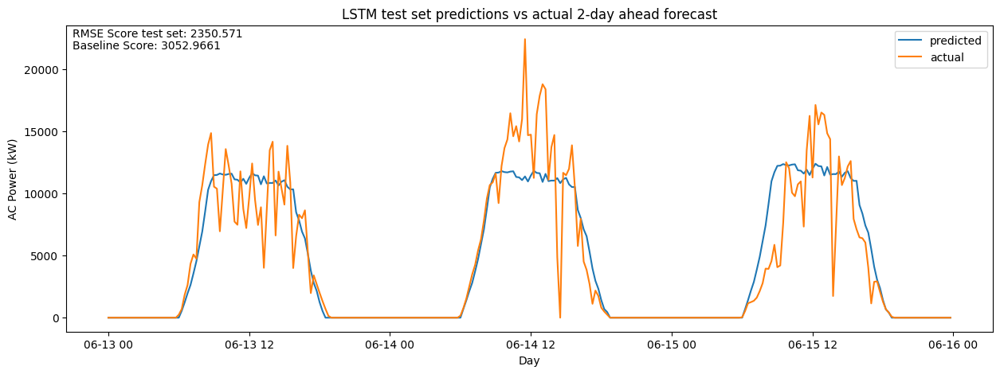

In [ ]:
df = data_preprocessing('Solar_Power_Plant_2_Generation_Data_Maharashta.csv',
                        'Solar_Power_Plant_2_Weather_Sensor_Data_Maharashta.csv',
                        imputer=KNNImputer(n_neighbors=10))

df = basic_features(df)
df = day_cos_sin(df, freq=1, type='cos')
target, cv_indices, baseline_score, forecast_length_days = target_cv_baseline(df, forecast_length_days = 2)
inputs_train_stack, labels_train_stack, val_stack, features = inputs_labels_creation(df, target=target,
                                                                                     cv_indices=cv_indices,
                                                                                     feature_list=['Day_cos_1'])
predictions, score_results, fig =  model_train(df, target=target,
                                               inputs_train_stack=inputs_train_stack,
                                               labels_train_stack=labels_train_stack,
                                               val_stack=val_stack,
                                               lstm_units=16, verbose=0,
                                               forecast_length_days=forecast_length_days,
                                               baseline_score = baseline_score,
                                               features=features)

Our model performs pretty much the same for the 2-days ahead forecast. This makes sense and is an advantage of our model finding the general shape of the target as opposed to attempting to match every peak and valley.

Conclusions
From a baseline model with a RMSE of 3699 kW over our test period of the last 3 days, we were able to come up with model that had a RMSE of ~2870 kW for a ~22% improvement in performance. It was interesting comparing the XGBoost models with the RNN/LSTM ones. The XGBoost based models initially preferred the simpler data where the inverters generation data was aggregated, whereas the deep learning model at first did better with the inverters separated. However, both models eventually settled on a much simpler model made from a limited set of features. There is good and bad to this. These simpler models are less likely to be completely wrong, but also less likely to be completely accurate. There were seemingly stretches in the models that did not score as well, that appeared to match the actual data almost exactly. Of course, this could always be coincidence. Ultimately, the RNN/LSTM model prevailed just slightly beating out (by ~2%) the XGBoost model on our 3-day test period.

Project Extensions
There are many further explorations that would be possible with this project. There is always more room for more fine-tuning of the model. Also, trying different kinds of models. ARMA (Autoregressive Moving Average) in particular would likely perform well. Using pycaret's compare_models function would be a good starting point for this. It would also be possible to bring in extra datasets; weather predictions, sunset/sunrise, etc. to help our model. Or a project that just focuses on inverter performance/maintenance needs might be interesting.